## Model comparison: Bulla (2023) HDF5 vs PyCoCo FINAL spectra

This notebook loads **one** POSSIS output file (Stokes *I* SEDs vs time and viewing angle) and compares it to your pipeline **FINAL** spectrum (`read_final_spectrum_linear`).

**HDF5 layout** (group `observables`): `stokes[...,0]` = *I*, `time` (s → days), `wave` (treated as **rest** wavelength in Å by default), `lbol`. Same convention as [`2023_bulla/make_lcs_hdf5.py`](../2023_bulla/make_lcs_hdf5.py):

- Observer wavelength: `λ_obs = λ_rest × (1 + z)` if `WAVE_IS_REST = True`.
- Flux scaling: `F_obs ∝ I × (1/D_L/Mpc)² / (1+z)` (matches the script’s `sncosmo.TimeSeriesSource` input).

**Viewing angle:** grid uses `cos θ = linspace(0, 1, N_obs)` and `θ = arccos(cos θ)` in degrees (polar angle; see Bulla/POSSIS docs for axis definition).

**Phase:** model `time_days` is assumed to be **days since merger** in the same sense as your `phase_days = MJD - t0`. Adjust `MODEL_PHASE_OFFSET_DAYS` if needed.

**Observed SED choice:** set `SED_SELECT_MODE = "phase"` and `TARGET_PHASE_DAYS` to pick the FINAL spectrum file whose epoch is **nearest** in phase (prints the actual file and Δphase). Use `SED_SELECT_MODE = "filename"` and optional `COMPARISON_FINAL_FILENAME` for the previous behavior.

**Viewing-angle query:** with `ANGLE_MODE = "single"`, set `COS_THETA_TARGET` (e.g. `0.35`) to use the nearest grid point on `cos θ = linspace(0, 1, N_obs)`; if `COS_THETA_TARGET` is `None`, `OBS_INDEX_SINGLE` is used as before.

**Units:** confirm POSSIS native units for `stokes` against the paper / README; this notebook applies the same scaling as `make_lcs_hdf5.py` so results are consistent with that workflow.

**Dependencies:** `pip install h5py`

### Where to edit plots

Look for the cells titled **"Plot (edit me)"** — adjust colors, limits, which angles, panels, etc. Compute cells above prepare `wl_obs_data`, `F_data`, `fe_data`, `blob`, `z`, `d_lum_mpc`, and angle arrays.

In [23]:
import glob
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18

import pipeline_config as pconf

_REPO = os.path.normpath(pconf.COCO_PATH.rstrip(os.sep))
_CODES_DIR = os.path.join(_REPO, "Codes")
if _CODES_DIR not in sys.path:
    sys.path.insert(0, _CODES_DIR)

from comparison_check_log_utils import (
    deduplicate_wavelength_flux,
    parse_final_stem,
    read_final_spectrum_linear,
    resolve_final_directory,
    stem_to_spec_mjd,
)
from model_comparison_helpers import (
    chi2_flux,
    chi2_vs_obs_indices,
    cos_theta_to_theta_deg,
    enumerate_final_spectrum_phases,
    interp_model_flux_to_wavelengths,
    load_bulla2019_txt,
    load_bulla_observables,
    model_flux_for_epoch_and_angle,
    nearest_obs_index_for_cos_theta,
    obs_indices_for_theta_deg_range,
    pick_final_by_nearest_phase,
    pooled_chi2_all_epochs_angles,
)

In [24]:
# ---------------------------------------------------------------------------
# Configuration (edit)
# ---------------------------------------------------------------------------
MODEL_HDF5 = os.path.join(
    _REPO,
    "2023_bulla",
    "nph1.0e+07_dyn0.005-0.20-0.20_wind0.050_fiducial.hdf5",
    #"nph2.0e+06_dyn0.005-0.20-0.20_wind0.050_simpleall_run1.hdf5"
)

COCO_PATH = pconf.COCO_PATH
SNNAME = "AT2017gfo"
DATALC_PATH = os.path.join(COCO_PATH, "Inputs", "Photometry", "4_LCs_late_extrapolated")
FINAL_FLUX_ON_DISK = "auto"
FINAL_VARIANT = "as_observed"
USE_RJF_FINAL_SPECTRA = False
USE_RYANV2_FINAL_SPECTRA = True  # if True: FINAL under twodim_ryanv2/... (NB6/7 *_ryanv2)
TWODIM_MODE_FOR_FINAL = pconf.MODE_EXTRAPOLATE_SHORT
TWODIM_PRODUCT_FOR_FINAL = pconf.SUBDIR_FULL_GP
TWODIM_BRANCH = pconf.final_spectra_twodim_branch(
    TWODIM_MODE_FOR_FINAL, TWODIM_PRODUCT_FOR_FINAL,
    use_rjf=USE_RJF_FINAL_SPECTRA and not USE_RYANV2_FINAL_SPECTRA,
    use_ryanv2=USE_RYANV2_FINAL_SPECTRA,
)

COSMOLOGY = Planck18
Z_OVERRIDE = None  # None -> read from Inputs/SNe_Info/info.dat
D_L_MPC_OVERRIDE = 40  # None -> from cosmology(Z)

WAVE_IS_REST = True
MODEL_PHASE_OFFSET_DAYS = 0.0  # add to data phase when matching model time axis
TIME_INTERP_MODEL = True

# Angle selection: "single" | "range" | "all"
ANGLE_MODE = "range"
OBS_INDEX_SINGLE = 0  # used when ANGLE_MODE == "single" and COS_THETA_TARGET is None
COS_THETA_TARGET = None  # e.g. 0.35 -> nearest grid cos θ; overrides index when set (single mode)
COS_THETA_MIN = 0.0
COS_THETA_MAX = 1.0
ANGLE_SUBSAMPLE_MAX = 12  # cap when ANGLE_MODE == "all"

# Observed FINAL spectrum: "phase" = nearest epoch to TARGET_PHASE_DAYS; "filename" = pick by name
SED_SELECT_MODE = "phase"  # "phase" | "filename"
TARGET_PHASE_DAYS = 1.5  # days since t0; required when SED_SELECT_MODE == "phase"
PHASE_MATCH_MAX_WARN = 0.15  # warn if |Δphase| exceeds this (days)
SHOW_NEAREST_PHASE_K = 1  # print this many nearest epochs when SED_SELECT_MODE == "phase"
FINAL_SUFFIXES_TO_LOAD = None  # optional: e.g. ("_FINAL_spec_FL.txt",); None = all *.txt
COMPARISON_FINAL_FILENAME = None  # used when SED_SELECT_MODE == "filename"; None = first sorted .txt
PHASE_REFERENCE_MJD = None  # None -> SN_EXPLOSION_MJD[SNNAME]

# Plot defaults (overridden in plot cells if you like)
FIGSIZE = (10, 6)
FIG_SAVE_PATH = None
FIG_SAVE_DPI = 150

data_dir = resolve_final_directory(
    COCO_PATH, SNNAME, FINAL_VARIANT, twodim_branch=TWODIM_BRANCH
)
print("FINAL dir:", data_dir)
print("Model file:", MODEL_HDF5)

FINAL dir: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/twodim_ryanv2/extrapolate/full_gp/as_observed
Model file: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/2023_bulla/nph1.0e+07_dyn0.005-0.20-0.20_wind0.050_fiducial.hdf5


In [3]:
def read_sn_redshift(coco_path: str, snname: str) -> float:
    path = os.path.join(coco_path, "Inputs", "SNe_Info", "info.dat")
    df = pd.read_csv(path, sep=r"\s+", comment="#")
    row = df.loc[df["Name"] == snname]
    return float(row.iloc[0]["z"])


z = float(Z_OVERRIDE) if Z_OVERRIDE is not None else read_sn_redshift(COCO_PATH, SNNAME)
d_lum_mpc = (
    float(D_L_MPC_OVERRIDE)
    if D_L_MPC_OVERRIDE is not None
    else float(COSMOLOGY.luminosity_distance(z).to("Mpc").value)
)
t0 = float(
    PHASE_REFERENCE_MJD
    if PHASE_REFERENCE_MJD is not None
    else pconf.SN_EXPLOSION_MJD[SNNAME]
)

print("z:", z)
print("D_L (Mpc):", d_lum_mpc)
print("t0 MJD:", t0)

blob = load_bulla_observables(MODEL_HDF5)
n_obs = blob["I_stokes"].shape[0]
cos_theta_grid, theta_deg_grid = cos_theta_to_theta_deg(n_obs)
print("Model: N_obs, N_t, N_w =", blob["I_stokes"].shape)
print("Model time days range:", float(np.min(blob["time_days"])), "…", float(np.max(blob["time_days"])))

obs_index_single_resolved = int(np.clip(OBS_INDEX_SINGLE, 0, n_obs - 1))
if ANGLE_MODE == "single" and COS_THETA_TARGET is not None:
    obs_index_single_resolved = nearest_obs_index_for_cos_theta(
        cos_theta_grid, float(COS_THETA_TARGET)
    )
    print(
        "COS_THETA_TARGET:",
        float(COS_THETA_TARGET),
        "-> grid cos θ =",
        float(cos_theta_grid[obs_index_single_resolved]),
        ", θ =",
        float(theta_deg_grid[obs_index_single_resolved]),
        "deg, obs_index =",
        obs_index_single_resolved,
    )
elif ANGLE_MODE == "single":
    print(
        "Single angle: OBS_INDEX_SINGLE =",
        obs_index_single_resolved,
        "(cos θ =",
        float(cos_theta_grid[obs_index_single_resolved]),
        ", θ =",
        float(theta_deg_grid[obs_index_single_resolved]),
        "deg)",
    )

z: 0.00984
D_L (Mpc): 40.0
t0 MJD: 57982.52851852
Model: N_obs, N_t, N_w = (11, 100, 1000)
Model time days range: 0.2051915173719659 … 30.778727605794874


In [4]:
# Load one observed FINAL spectrum
specs = sorted(f for f in os.listdir(data_dir) if f.endswith(".txt"))
if not specs:
    raise FileNotFoundError("No .txt in %s" % data_dir)

if SED_SELECT_MODE == "filename":
    fname = COMPARISON_FINAL_FILENAME or specs[0]
    if fname not in specs:
        raise FileNotFoundError("%s not in FINAL dir" % fname)
elif SED_SELECT_MODE == "phase":
    if TARGET_PHASE_DAYS is None:
        raise ValueError("TARGET_PHASE_DAYS must be set when SED_SELECT_MODE == 'phase'")
    phase_rows = enumerate_final_spectrum_phases(
        data_dir,
        COCO_PATH,
        SNNAME,
        DATALC_PATH,
        t0_mjd=float(t0),
        final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    )
    if not phase_rows:
        raise ValueError("No matching FINAL spectra in %s" % data_dir)
    picked = pick_final_by_nearest_phase(phase_rows, float(TARGET_PHASE_DAYS))
    fname = picked["fname"]
    if picked["abs_delta_phase_days"] > float(PHASE_MATCH_MAX_WARN):
        warnings.warn(
            "Nearest spectrum phase differs from TARGET_PHASE_DAYS by %.4f d (threshold %.4f)"
            % (picked["abs_delta_phase_days"], float(PHASE_MATCH_MAX_WARN)),
            UserWarning,
        )
    print("SED_SELECT_MODE=phase: target phase_days =", float(TARGET_PHASE_DAYS))
    print(
        "Chosen file:",
        picked["fname"],
        "| phase_days =",
        picked["phase_days"],
        "| Δphase =",
        picked["delta_phase_days"],
    )
    k = int(SHOW_NEAREST_PHASE_K)
    if k > 0:
        near = sorted(
            phase_rows, key=lambda r: abs(float(r["phase_days"]) - float(TARGET_PHASE_DAYS))
        )[:k]
        print("%d nearest epochs (by |Δphase|):" % k)
        for r in near:
            dph = float(r["phase_days"]) - float(TARGET_PHASE_DAYS)
            print(" ", r["fname"], "phase_days=", r["phase_days"], "Δphase=", dph)
else:
    raise ValueError("SED_SELECT_MODE must be 'phase' or 'filename'")

path_obs = os.path.join(data_dir, fname)
wl_data, F_data, fe_data = read_final_spectrum_linear(path_obs, flux_on_disk=FINAL_FLUX_ON_DISK)
m = np.isfinite(wl_data) & np.isfinite(F_data) & np.isfinite(fe_data)
wl_data, F_data, fe_data = wl_data[m], F_data[m], fe_data[m]
order = np.argsort(wl_data)
wl_data, F_data, fe_data = wl_data[order], F_data[order], fe_data[order]
wl_data, F_data, fe_data = deduplicate_wavelength_flux(wl_data, F_data, fe_data)

stem = parse_final_stem(fname)
mjd_obs = stem_to_spec_mjd(stem, COCO_PATH, SNNAME, datalc_path=DATALC_PATH)
phase_days_data = float(mjd_obs - t0)
phase_model_match = phase_days_data + MODEL_PHASE_OFFSET_DAYS

print("File:", fname)
print("MJD:", mjd_obs, "phase_days:", phase_days_data)
print("phase used for model match:", phase_model_match)

SED_SELECT_MODE=phase: target phase_days = 1.5
Chosen file: 0.181958_FINAL_spec.txt | phase_days = 1.5184226527053397 | Δphase = 0.018422652705339715
1 nearest epochs (by |Δphase|):
  0.181958_FINAL_spec.txt phase_days= 1.5184226527053397 Δphase= 0.018422652705339715
File: 0.181958_FINAL_spec.txt
MJD: 57984.0469411727 phase_days: 1.5184226527053397
phase used for model match: 1.5184226527053397


In [5]:
def select_obs_indices(angle_mode: str, n_obs: int):
    if angle_mode == "single":
        return [int(np.clip(obs_index_single_resolved, 0, n_obs - 1))]
    if angle_mode == "all":
        idx = np.arange(n_obs)
        if idx.size > ANGLE_SUBSAMPLE_MAX:
            idx = np.unique(
                np.linspace(0, n_obs - 1, ANGLE_SUBSAMPLE_MAX).astype(int)
            )
        return list(idx)
    if angle_mode == "range":
        m = (cos_theta_grid >= COS_THETA_MIN) & (cos_theta_grid <= COS_THETA_MAX)
        return np.where(m)[0].tolist()
    raise ValueError("ANGLE_MODE must be single|range|all")


obs_indices_plot = select_obs_indices(ANGLE_MODE, n_obs)
if not obs_indices_plot:
    obs_indices_plot = [0]
print("Obs indices for plots:", obs_indices_plot)

Obs indices for plots: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


### Plot (edit me) — model vs data, F_λ vs λ

Edit styling, log axes, wavelength limits, angle subsampling, labels, etc.

In [ ]:
# --- Plot (edit me): spectrum comparison ---
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    wl_data,
    F_data,
    color="0.15",
    lw=1.4,
    label="Data (%s)" % fname,
    zorder=1000
)
ax.fill_between(
    wl_data,
    F_data - fe_data,
    F_data + fe_data,
    color="0.15",
    alpha=0.2,
)

cmap = plt.cm.viridis
for k, oi in enumerate(obs_indices_plot):
    wl_m, F_m, _ = model_flux_for_epoch_and_angle(
        blob,
        obs_index=oi,
        phase_days_target=phase_model_match,
        z=z,
        d_lum_mpc=d_lum_mpc,
        wave_is_rest=WAVE_IS_REST,
        time_interp=TIME_INTERP_MODEL,
    )
    color = cmap(0.15 + 0.75 * k / max(len(obs_indices_plot) - 1, 1))
    ax.plot(
        wl_m,
        F_m,
        lw=1.2,
        alpha=0.5,
        color=color,
        label="Model cosθ=%.3f (%.1f°)" % (cos_theta_grid[oi], theta_deg_grid[oi]),
    )

ax.set_xlim(0, 25000)
#ax.set_ylim(0, 8e-16)
ax.set_xlabel(r"$\lambda$ ($\AA$) observer", fontsize=14)
ax.set_ylabel(r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA$$^{-1}$)", fontsize=14)
ax.set_title(
    "%s phase=%.2f d | z=%.5f $D_L$=%.1f Mpc"
    % (SNNAME, phase_days_data, z, d_lum_mpc)
)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.35)
fig.tight_layout()
if FIG_SAVE_PATH:
    fig.savefig(FIG_SAVE_PATH, dpi=FIG_SAVE_DPI, bbox_inches="tight")
plt.show()

### Plot (edit me): multiple Bulla models at one angle

Overlays **one** model SED per `*.hdf5` in `2023_bulla`, all at the same viewing angle (target **cos θ** or optional fixed observer index). The observed spectrum is unchanged from the cells above.

In [ ]:
# --- Plot (edit me): multiple Bulla models at one viewing angle ---
MULTI_MODEL_DIR = os.path.join(_REPO, "2023_bulla")
MULTI_MODEL_PATHS = sorted(glob.glob(os.path.join(MULTI_MODEL_DIR, "*.hdf5")))
MULTI_MODEL_COS_THETA = 0.8  # nearest grid point per file (ignored if MULTI_MODEL_OBS_INDEX is set)
MULTI_MODEL_OBS_INDEX = None  # if int, use this observer index (clipped per file) instead of cos θ
MULTI_MODEL_MAX_FILES = None  # e.g. 8 to limit legend size
FIGSIZE_MULTI = FIGSIZE
FIG_SAVE_PATH_MULTI = None
FIG_SAVE_DPI_MULTI = FIG_SAVE_DPI

_paths = list(MULTI_MODEL_PATHS)
if MULTI_MODEL_MAX_FILES is not None:
    _paths = _paths[: int(MULTI_MODEL_MAX_FILES)]

plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(figsize=FIGSIZE_MULTI)

ax.plot(
    wl_data,
    F_data,
    color="0.15",
    lw=1.4,
    label="Data (%s)" % fname,
    zorder=1000,
)
ax.fill_between(
    wl_data,
    F_data - fe_data,
    F_data + fe_data,
    color="0.15",
    alpha=0.2,
)

cmap = plt.cm.viridis
n_m = max(len(_paths), 1)
for k, h5_path in enumerate(_paths):
    blob_m = load_bulla_observables(h5_path)
    n_obs_m = blob_m["I_stokes"].shape[0]
    cos_g, th_g = cos_theta_to_theta_deg(n_obs_m)
    if MULTI_MODEL_OBS_INDEX is not None:
        oi = int(np.clip(int(MULTI_MODEL_OBS_INDEX), 0, n_obs_m - 1))
    else:
        oi = nearest_obs_index_for_cos_theta(cos_g, float(MULTI_MODEL_COS_THETA))
    wl_m, F_m, _ = model_flux_for_epoch_and_angle(
        blob_m,
        obs_index=oi,
        phase_days_target=phase_model_match,
        z=z,
        d_lum_mpc=d_lum_mpc,
        wave_is_rest=WAVE_IS_REST,
        time_interp=TIME_INTERP_MODEL,
    )
    color = cmap(0.15 + 0.75 * k / max(n_m - 1, 1))
    stem = os.path.splitext(os.path.basename(h5_path))[0]
    label = "%s  cosθ=%.3f (%.1f°)" % (stem, float(cos_g[oi]), float(th_g[oi]))
    ax.plot(
        wl_m,
        F_m,
        lw=1.2,
        alpha=0.5,
        color=color,
        label=label,
    )

ax.set_xlim(0, 25000)
# ax.set_ylim(0, 8e-16)
ax.set_xlabel(r"$\lambda$ ($\AA$) observer", fontsize=14)
ax.set_ylabel(r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA$$^{-1}$)", fontsize=14)
_theta_note = (
    "obs_index=%d" % int(MULTI_MODEL_OBS_INDEX)
    if MULTI_MODEL_OBS_INDEX is not None
    else "cosθ_target=%.3f" % float(MULTI_MODEL_COS_THETA)
)
ax.set_title(
    "%s phase=%.2f d | z=%.5f $D_L$=%.1f Mpc | %s | N=%d models"
    % (SNNAME, phase_days_data, z, d_lum_mpc, _theta_note, len(_paths))
)
ax.legend(loc="best", fontsize=7)
ax.grid(True, alpha=0.35)
fig.tight_layout()
if FIG_SAVE_PATH_MULTI:
    fig.savefig(FIG_SAVE_PATH_MULTI, dpi=FIG_SAVE_DPI_MULTI, bbox_inches="tight")
plt.show()

### Plot (edit me) — χ² vs viewing angle (single epoch)

Uses the same data spectrum and `phase_model_match` as above; scans observer indices (optionally restrict via `COS_THETA_MIN`/`MAX` by setting `chi2_obs_indices`).

In [ ]:
# --- Plot (edit me): chi^2 vs cos(theta) ---
# Full angle scan (subsampled); edit to match obs_indices_plot only if you want
chi2_obs_indices = select_obs_indices("all", n_obs)
rows = chi2_vs_obs_indices(
    wl_data,
    F_data,
    fe_data,
    blob,
    phase_days_target=phase_model_match,
    z=z,
    d_lum_mpc=d_lum_mpc,
    obs_indices=chi2_obs_indices,
    wave_is_rest=WAVE_IS_REST,
    time_interp=TIME_INTERP_MODEL,
)
tab = pd.DataFrame(rows).sort_values("cos_theta")
print(tab.head(20))

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(tab["cos_theta"], tab["chi2"], "o-", color="darkgreen", lw=1.2, ms=5)
ax.set_xlabel(r"$\cos\theta$", fontsize=14)
ax.set_ylabel(r"$\chi^2$ (binned pixels)", fontsize=14)
ax.set_title("%s — model vs data (one epoch)" % SNNAME)
ax.grid(True, alpha=0.35)
fig.tight_layout()
if FIG_SAVE_PATH:
    p2 = os.path.splitext(str(FIG_SAVE_PATH))[0] + "_chi2.png"
    fig.savefig(p2, dpi=FIG_SAVE_DPI, bbox_inches="tight")
plt.show()

### Plot (edit me): **top-ranked** Bulla models at one phase

Set **`TOP5_PHASE_DAYS_TARGET`** (days since t₀); the FINAL spectrum nearest in phase is used. Each `*.hdf5` is scored by **best χ²_red** over viewing angles (**optional θ ∈ [LOW, HIGH]°** via `TOP5_USE_THETA_BAND`; else all grid angles). **`TOP5_K`** models (default 5) are overlaid with the data.



In [ ]:
# --- Plot (edit me): top K Bulla models at chosen phase (best angle per HDF5) ---
TOP5_PHASE_DAYS_TARGET = 7.44  # days since t0; nearest FINAL spectrum is used
TOP5_MODEL_DIR = os.path.join(_REPO, "2023_bulla")
TOP5_PATHS = sorted(glob.glob(os.path.join(TOP5_MODEL_DIR, "*.hdf5")))
TOP5_K = 5
TOP5_MAX_MODEL_FILES = None  # truncate scan list for speed
TOP5_USE_THETA_BAND = True  # True: restrict θ via TOP5_THETA_* (same helpers as pooled cells)
TOP5_THETA_LO_DEG = 13.0
TOP5_THETA_HI_DEG = 45.0
TOP5_UNCERTAINTY_SCALE = 1.0  # multiply all data σ before χ²

FIGSIZE_TOP5 = FIGSIZE
FIG_SAVE_PATH_TOP5 = None
FIG_SAVE_DPI_TOP5 = FIG_SAVE_DPI

_phase_rows_top5 = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
if not _phase_rows_top5:
    raise ValueError("No FINAL spectra for top-5 plot")
_picked_t5 = pick_final_by_nearest_phase(
    _phase_rows_top5, float(TOP5_PHASE_DAYS_TARGET)
)
if _picked_t5["abs_delta_phase_days"] > float(PHASE_MATCH_MAX_WARN):
    warnings.warn(
        "Top5 plot: target %.3f d -> %s |Δphase|=%.4f d"
        % (
            float(TOP5_PHASE_DAYS_TARGET),
            _picked_t5["fname"],
            _picked_t5["abs_delta_phase_days"],
        ),
        UserWarning,
    )

_path_t5 = os.path.join(data_dir, _picked_t5["fname"])
wl_t5, F_t5, fe_t5 = read_final_spectrum_linear(
    _path_t5, flux_on_disk=FINAL_FLUX_ON_DISK
)
_m = np.isfinite(wl_t5) & np.isfinite(F_t5) & np.isfinite(fe_t5)
wl_t5, F_t5, fe_t5 = wl_t5[_m], F_t5[_m], fe_t5[_m]
_ord = np.argsort(wl_t5)
wl_t5, F_t5, fe_t5 = wl_t5[_ord], F_t5[_ord], fe_t5[_ord]
wl_t5, F_t5, fe_t5 = deduplicate_wavelength_flux(wl_t5, F_t5, fe_t5)
fe_t5 = np.asarray(fe_t5, dtype=float) * float(TOP5_UNCERTAINTY_SCALE)

phase_days_data_t5 = float(_picked_t5["phase_days"])
phase_model_top5 = phase_days_data_t5 + float(MODEL_PHASE_OFFSET_DAYS)
fname_top5 = _picked_t5["fname"]

_t5paths = list(TOP5_PATHS)
if TOP5_MAX_MODEL_FILES is not None:
    _t5paths = _t5paths[: int(TOP5_MAX_MODEL_FILES)]

_score_rows = []
for _h5_t5 in _t5paths:
    _stem_t5 = os.path.splitext(os.path.basename(_h5_t5))[0]
    _blob_t5 = load_bulla_observables(_h5_t5)
    _n_ot5 = _blob_t5["I_stokes"].shape[0]
    if TOP5_USE_THETA_BAND:
        _ois_t5 = obs_indices_for_theta_deg_range(
            _n_ot5, TOP5_THETA_LO_DEG, TOP5_THETA_HI_DEG
        )
    else:
        _ois_t5 = list(range(_n_ot5))
    if not _ois_t5:
        continue
    _rows_t5 = chi2_vs_obs_indices(
        wl_t5,
        F_t5,
        fe_t5,
        _blob_t5,
        phase_days_target=phase_model_top5,
        z=z,
        d_lum_mpc=d_lum_mpc,
        obs_indices=_ois_t5,
        wave_is_rest=WAVE_IS_REST,
        time_interp=TIME_INTERP_MODEL,
    )
    _best_t5 = min(
        _rows_t5,
        key=lambda rr: (
            float(rr["chi2"]) / float(rr["n_pix"]) if rr["n_pix"] > 0 else float("inf")
        ),
    )
    _npix = int(_best_t5["n_pix"])
    _chi2_red = float(_best_t5["chi2"]) / float(_npix) if _npix > 0 else float("nan")
    _score_rows.append(
        {
            "path": _h5_t5,
            "stem": _stem_t5,
            "obs_index": int(_best_t5["obs_index"]),
            "cos_theta": float(_best_t5["cos_theta"]),
            "theta_deg": float(_best_t5["theta_deg"]),
            "chi2": float(_best_t5["chi2"]),
            "n_pix": _npix,
            "chi2_red": _chi2_red,
        }
    )

_tab_t5 = pd.DataFrame(_score_rows).sort_values("chi2_red")
if len(_tab_t5) == 0:
    raise ValueError(
        "No HDF5 yielded scores — check TOP5_PATHS, angle band, or model directory."
    )
_top_t5 = _tab_t5.head(int(TOP5_K))
print(_top_t5.to_string(index=False))

plt.rcParams["font.family"] = "serif"
fig_t5, ax_t5 = plt.subplots(figsize=FIGSIZE_TOP5)
ax_t5.plot(
    wl_t5,
    F_t5,
    color="0.15",
    lw=1.4,
    label="Data (%s)" % fname_top5,
    zorder=1000,
)
ax_t5.fill_between(
    wl_t5,
    F_t5 - fe_t5,
    F_t5 + fe_t5,
    color="0.15",
    alpha=0.2,
)

_cmap_t5 = plt.cm.viridis
_n_tt = max(len(_top_t5), 1)
for _k_t5, __r in enumerate(_top_t5.itertuples()):
    _blob_p = load_bulla_observables(__r.path)
    wl_m, F_m, _ = model_flux_for_epoch_and_angle(
        _blob_p,
        obs_index=int(__r.obs_index),
        phase_days_target=phase_model_top5,
        z=z,
        d_lum_mpc=d_lum_mpc,
        wave_is_rest=WAVE_IS_REST,
        time_interp=TIME_INTERP_MODEL,
    )
    color = _cmap_t5(0.15 + 0.75 * _k_t5 / max(_n_tt - 1, 1))
    _stem_short = __r.stem[:36] + ("…" if len(__r.stem) > 36 else "")
    _lab_t5 = (
        r"%s  $\chi^2_{\mathrm{red}}=%.2f$  $\cos\theta=%.3f$ (%.1f$^\circ$)"
        % (
            _stem_short,
            float(__r.chi2_red),
            float(__r.cos_theta),
            float(__r.theta_deg),
        )
    )
    ax_t5.plot(
        wl_m,
        F_m,
        lw=1.35,
        alpha=0.75,
        color=color,
        label=_lab_t5,
    )

ax_t5.set_xlim(0, 25000)
ax_t5.set_xlabel(r"$\lambda$ ($\AA$) observer", fontsize=14)
ax_t5.set_ylabel(
    r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)", fontsize=14
)
_theta_note_t5 = (
    r"$\theta\in[%.0f^\circ,%.0f^\circ]$ profile / file"
    % (TOP5_THETA_LO_DEG, TOP5_THETA_HI_DEG)
    if TOP5_USE_THETA_BAND
    else r"$\chi^2_{\rm red}$ min over full angle grid per file"
)
ax_t5.set_title(
    "%s phase=%.2f d (target %.2f d) | z=%.5f $D_L$=%.1f Mpc | top %d models | %s"
    % (
        SNNAME,
        phase_days_data_t5,
        float(TOP5_PHASE_DAYS_TARGET),
        z,
        d_lum_mpc,
        int(TOP5_K),
        _theta_note_t5,
    )
)
ax_t5.legend(loc="best", fontsize=6)
ax_t5.grid(True, alpha=0.35)
fig_t5.tight_layout()
if FIG_SAVE_PATH_TOP5:
    fig_t5.savefig(
        FIG_SAVE_PATH_TOP5, dpi=FIG_SAVE_DPI_TOP5, bbox_inches="tight"
    )
plt.show()



### Plot / diagnostic: reduced χ² vs Bulla model (fixed phase & angle)

For one model time (days on the Bulla grid) and one viewing angle, compute **reduced χ² = χ² / n_pix** for each `*.hdf5` in `2023_bulla` using the **currently loaded** data spectrum. Here ν ≈ n_pix per model (no parameters fit); interpret like [`model_chi2.py`](model_chi2.py).

In [ ]:
# --- Diagnostic: reduced chi^2 vs model (fixed phase & angle) ---
# chi2_red = chi2 / n_pix with nu ~ n_pix (no fitted parameters per comparison).
REDCHI2_MODEL_DIR = os.path.join(_REPO, "2023_bulla")
REDCHI2_PHASE_DAYS = phase_model_match  # Bulla model time (days); override to scan another epoch
REDCHI2_COS_THETA = 0.8  # nearest grid point per file; ignored if REDCHI2_OBS_INDEX is set
REDCHI2_OBS_INDEX = None  # if int, use this observer index (clipped per file) instead of cos theta
REDCHI2_MAX_MODELS = None  # e.g. 14 to cap
FIG_SAVE_PATH_REDCHI2 = None  # e.g. "redchi2_vs_model.png" next to other saves
FIG_SAVE_DPI_REDCHI2 = FIG_SAVE_DPI

red_paths = sorted(glob.glob(os.path.join(REDCHI2_MODEL_DIR, "*.hdf5")))
if REDCHI2_MAX_MODELS is not None:
    red_paths = red_paths[: int(REDCHI2_MAX_MODELS)]

if not red_paths:
    print("No *.hdf5 in", REDCHI2_MODEL_DIR)
else:
    red_rows = []
    for h5_path in red_paths:
        blob_r = load_bulla_observables(h5_path)
        n_obs_r = blob_r["I_stokes"].shape[0]
        cos_gr, th_gr = cos_theta_to_theta_deg(n_obs_r)
        if REDCHI2_OBS_INDEX is not None:
            oi_r = int(np.clip(int(REDCHI2_OBS_INDEX), 0, n_obs_r - 1))
        else:
            oi_r = nearest_obs_index_for_cos_theta(cos_gr, float(REDCHI2_COS_THETA))
        wl_mr, F_mr, _ = model_flux_for_epoch_and_angle(
            blob_r,
            obs_index=oi_r,
            phase_days_target=float(REDCHI2_PHASE_DAYS),
            z=z,
            d_lum_mpc=d_lum_mpc,
            wave_is_rest=WAVE_IS_REST,
            time_interp=TIME_INTERP_MODEL,
        )
        F_on_r = interp_model_flux_to_wavelengths(wl_mr, F_mr, wl_data)
        c2_r, n_r = chi2_flux(F_data, F_on_r, fe_data)
        chi2_red_r = float(c2_r) / float(n_r) if n_r > 0 else float("nan")
        red_rows.append(
            {
                "model_basename": os.path.basename(h5_path),
                "model_stem": os.path.splitext(os.path.basename(h5_path))[0],
                "obs_index": oi_r,
                "cos_theta": float(cos_gr[oi_r]),
                "theta_deg": float(th_gr[oi_r]),
                "chi2": float(c2_r),
                "n_pix": int(n_r),
                "chi2_red": chi2_red_r,
            }
        )

    tab_red = pd.DataFrame(red_rows).sort_values("chi2_red")
    print(tab_red.to_string(index=False))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    x = np.arange(len(tab_red))
    bars = ax.bar(x, tab_red["chi2_red"].values, color="steelblue", edgecolor="none")
    imin = int(np.nanargmin(tab_red["chi2_red"].values))
    bars[imin].set_color("crimson")
    ax.set_xticks(x)
    ax.set_xticklabels(tab_red["model_stem"].values, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel(r"$\chi^2_{\rm red} = \chi^2 / n_{\rm pix}$", fontsize=14)
    ax.set_xlabel("Bulla model (HDF5 stem)", fontsize=14)
    _phase_note = float(REDCHI2_PHASE_DAYS)
    _ang_note = (
        "obs_index=%d" % int(REDCHI2_OBS_INDEX)
        if REDCHI2_OBS_INDEX is not None
        else "cosθ_target=%.3f" % float(REDCHI2_COS_THETA)
    )
    ax.set_title(
        "%s — reduced $\\chi^2$ vs model | phase=%.3f d | %s"
        % (SNNAME, _phase_note, _ang_note)
    )
    ax.grid(True, axis="y", alpha=0.35)
    fig.tight_layout()
    if FIG_SAVE_PATH_REDCHI2:
        fig.savefig(
            FIG_SAVE_PATH_REDCHI2, dpi=FIG_SAVE_DPI_REDCHI2, bbox_inches="tight"
        )
    plt.show()

### Global pooled χ²: all epochs × all angles

For each Bulla HDF5, we sum χ² over **every** target FINAL epoch (nearest spectrum to each target phase) and **every** observer index on that model grid, then **χ²_red = χ²_tot / N_tot**. The **best overall** model minimizes this (for identical valid-pixel counts across models; if `N_obs` differs between files, compare `χ²_tot` as well).

**Uncertainty scaling:** multiplying all data errors by the **same** factor scales every model’s χ² by **1/s²**, so **model ranking does not change**. Inflating σ until the best model has χ²_red ≈ 1 is useful for **reporting** (errors may be underestimated); comparing **χ²_red / χ²_red_min** is equivalent for ranking.

**θ band (optional):** set `POOL_USE_THETA_BAND = True` with `POOL_THETA_LO_DEG` / `POOL_THETA_HI_DEG` (e.g. 13–45°) in the global-pool code cell so χ² sums only over observer indices whose θ falls in that range. Same flag in the all-FINAL pooled cell (keep values in sync if you run both). Equal weight per index is roughly uniform on discrete **cos θ**, not strictly π(θ) uniform in θ unless you add Jacobian-style weights.


In [ ]:
# --- Global pooled chi^2 over many epochs and all angles (per Bulla model) ---
GLOBAL_CHI2_PHASE_TARGETS = [0.5 + float(i) for i in range(24)]  # days since t0; edit list as needed
GLOBAL_CHI2_BULLA_DIR = os.path.join(_REPO, "2023_bulla")
GLOBAL_CHI2_MAX_MODELS = None
UNCERTAINTY_SCALE_GLOBAL = 1.0  # multiply all data uncertainties; ranking unchanged for any fixed value > 0
GLOBAL_CHI2_AUTO_SCALE_DISPLAY = True  # bar plot chi2_red / min(chi2_red) so best model is 1.0
FIG_SAVE_PATH_GLOBAL_CHI2 = None
FIG_SAVE_DPI_GLOBAL_CHI2 =150

# Viewing-angle θ band (hard support / prior): pool χ² only over θ in [LO, HI] ° (discrete grid)
POOL_USE_THETA_BAND = False
POOL_THETA_LO_DEG = 13.0
POOL_THETA_HI_DEG = 45.0

phase_rows_global = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
if not phase_rows_global:
    raise ValueError("No FINAL spectra for global chi2; check data_dir / suffixes")

epochs_pool = []
for tgt in GLOBAL_CHI2_PHASE_TARGETS:
    picked_g = pick_final_by_nearest_phase(phase_rows_global, float(tgt))
    if picked_g["abs_delta_phase_days"] > float(PHASE_MATCH_MAX_WARN):
        warnings.warn(
            "Global pool: target %.2f d -> %s |Δphase|=%.4f d"
            % (tgt, picked_g["fname"], picked_g["abs_delta_phase_days"]),
            UserWarning,
        )
    path_g = os.path.join(data_dir, picked_g["fname"])
    wl_g, F_g, fe_g = read_final_spectrum_linear(
        path_g, flux_on_disk=FINAL_FLUX_ON_DISK
    )
    msk = np.isfinite(wl_g) & np.isfinite(F_g) & np.isfinite(fe_g)
    wl_g, F_g, fe_g = wl_g[msk], F_g[msk], fe_g[msk]
    ord_g = np.argsort(wl_g)
    wl_g, F_g, fe_g = wl_g[ord_g], F_g[ord_g], fe_g[ord_g]
    wl_g, F_g, fe_g = deduplicate_wavelength_flux(wl_g, F_g, fe_g)
    epochs_pool.append(
        {
            "wl_data": wl_g,
            "F_data": F_g,
            "fe_data": fe_g,
            "phase_model_days": float(picked_g["phase_days"])
            + float(MODEL_PHASE_OFFSET_DAYS),
            "target_phase_days": float(tgt),
            "spectrum_fname": picked_g["fname"],
        }
    )

print(
    "Global pool: %d epochs × %s; phase targets: %s"
    % (
        len(epochs_pool),
        (
            "θ∈[%.1f°, %.1f°] (observer indices)"
            % (POOL_THETA_LO_DEG, POOL_THETA_HI_DEG)
            if POOL_USE_THETA_BAND
            else "all angles"
        ),
        GLOBAL_CHI2_PHASE_TARGETS,
    )
)

pool_paths = sorted(glob.glob(os.path.join(GLOBAL_CHI2_BULLA_DIR, "*.hdf5")))
if GLOBAL_CHI2_MAX_MODELS is not None:
    pool_paths = pool_paths[: int(GLOBAL_CHI2_MAX_MODELS)]
if not pool_paths:
    print("No *.hdf5 in", GLOBAL_CHI2_BULLA_DIR)
else:
    pool_rows = []
    for h5_g in pool_paths:
        blob_g = load_bulla_observables(h5_g)
        n_obs_g = blob_g["I_stokes"].shape[0]
        oi_global = (
            obs_indices_for_theta_deg_range(
                n_obs_g, POOL_THETA_LO_DEG, POOL_THETA_HI_DEG
            )
            if POOL_USE_THETA_BAND
            else None
        )
        c2_tot, n_tot = pooled_chi2_all_epochs_angles(
            blob_g,
            epochs_pool,
            z=z,
            d_lum_mpc=d_lum_mpc,
            wave_is_rest=WAVE_IS_REST,
            time_interp=TIME_INTERP_MODEL,
            uncertainty_scale=UNCERTAINTY_SCALE_GLOBAL,
            obs_indices=oi_global,
        )
        cr = float(c2_tot) / float(n_tot) if n_tot > 0 else float("nan")
        pool_rows.append(
            {
                "model_stem": os.path.splitext(os.path.basename(h5_g))[0],
                "chi2_tot": float(c2_tot),
                "n_pix_tot": int(n_tot),
                "chi2_red": cr,
            }
        )

    tab_pool = pd.DataFrame(pool_rows).sort_values("chi2_red")
    if GLOBAL_CHI2_AUTO_SCALE_DISPLAY and np.isfinite(tab_pool["chi2_red"].min()):
        tab_pool["chi2_red_display"] = tab_pool["chi2_red"] / float(
            tab_pool["chi2_red"].min()
        )
    else:
        tab_pool["chi2_red_display"] = tab_pool["chi2_red"]

    print(tab_pool.to_string(index=False))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    xp = np.arange(len(tab_pool))
    yplot = tab_pool["chi2_red_display"].values
    bars = ax.bar(xp, yplot, color="steelblue", edgecolor="none")
    imn = int(np.nanargmin(yplot))
    bars[imn].set_color("crimson")
    ax.set_xticks(xp)
    ax.set_xticklabels(tab_pool["model_stem"].values, rotation=45, ha="right", fontsize=7)
    ylab = (
        r"$\chi^2_{\rm red} / \chi^2_{\rm red, min}$"
        if GLOBAL_CHI2_AUTO_SCALE_DISPLAY
        else r"$\chi^2_{\rm red}$ (pooled)"
    )
    ax.set_ylabel(ylab, fontsize=14)
    ax.set_xlabel("Bulla model", fontsize=14)
    ax.set_title(
        "%s — pooled over %d epochs, %s | scale$_{\\sigma}$=%.3g"
        % (
            SNNAME,
            len(epochs_pool),
            (
                "$\\theta\\in[%.1f°,%.1f°]$ (discrete grid)"
                % (POOL_THETA_LO_DEG, POOL_THETA_HI_DEG)
                if POOL_USE_THETA_BAND
                else "all angles"
            ),
            UNCERTAINTY_SCALE_GLOBAL,
        )
    )
    ax.grid(True, axis="y", alpha=0.35)
    fig.tight_layout()
    if FIG_SAVE_PATH_GLOBAL_CHI2:
        fig.savefig(
            FIG_SAVE_PATH_GLOBAL_CHI2, dpi=FIG_SAVE_DPI_GLOBAL_CHI2, bbox_inches="tight"
        )
    plt.show()

### Pooled χ² using **every** FINAL spectrum file

Builds one epoch per `*.txt` in your FINAL directory (via `enumerate_final_spectrum_phases`), then pools χ² over all of them.

**`POOL_ALL_ANGLE_SCOPE`:** `"all"` sums over **every** viewing angle on each HDF5 grid (strict). `"fixed_cos_theta"` uses **one** angle per model file (`POOL_ALL_FIXED_COS_THETA`, nearest grid point) or **`POOL_ALL_FIXED_OBS_INDEX`** if set.

**`POOL_USE_THETA_BAND`:** when `True`, overrides `POOL_ALL_ANGLE_SCOPE` and pools only over θ in `[POOL_THETA_LO_DEG, POOL_THETA_HI_DEG]` (see helper `obs_indices_for_theta_deg_range`; cos-θ-grid caveat applies).

All-files pool: 266 epochs | angles: scope=fixed_cos_theta | phase_days: 0.001 … 25.200 d
First/last files: -2.958607_FINAL_spec_FL.txt … 1.401393_FINAL_spec_FL.txt
                                                             model_stem     chi2_tot  n_pix_tot    chi2_red  chi2_red_display
nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.40 2.966515e+06      22962  129.192351          1.000000
nph1.0e+06_MDyn0.001_vDyn0.20_YeDyn0.25_MWind0.130_vWind0.15_YeWind0.40 6.892448e+06      22962  300.167588          2.323416
nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.20 1.648467e+08      22962 7179.110492         55.569161


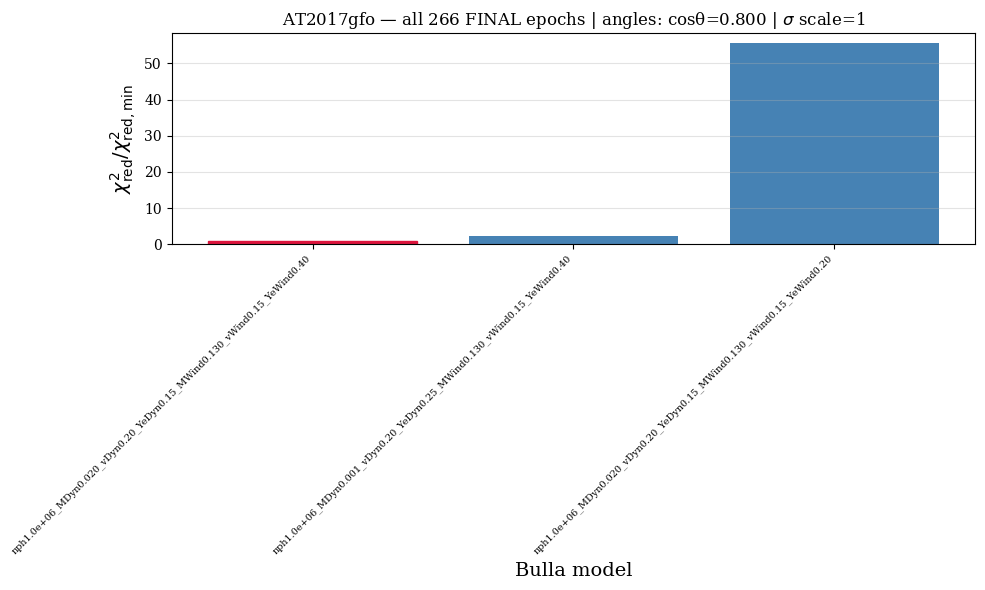

In [26]:
# --- Pooled chi^2: ALL FINAL spectrum files (one epoch per .txt) ---
POOL_ALL_BULLA_DIR = os.path.join(_REPO, "2023_bulla")
POOL_ALL_MAX_MODELS = None
# "all" = sum chi2 over every observer index on each model; "fixed_cos_theta" = one angle per file
POOL_ALL_ANGLE_SCOPE = "fixed_cos_theta"  # "all" | "fixed_cos_theta"
POOL_ALL_FIXED_COS_THETA = 0.80
POOL_ALL_FIXED_OBS_INDEX = None  # if int, overrides cos θ (clipped per file)
POOL_ALL_UNCERTAINTY_SCALE = 1.0
POOL_ALL_AUTO_SCALE_DISPLAY = True
FIG_SAVE_PATH_POOL_ALL = None
FIG_SAVE_DPI_POOL_ALL = FIG_SAVE_DPI
POOL_USE_THETA_BAND = False

try:
    POOL_USE_THETA_BAND
except NameError:
    POOL_USE_THETA_BAND = False  # duplicate defaults if global-pool cell above was not run
    POOL_THETA_LO_DEG = 13.0
    POOL_THETA_HI_DEG = 45.0

phase_rows_allfiles = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
if not phase_rows_allfiles:
    raise ValueError("No FINAL spectra for all-files pool")

epochs_allfiles = []
for row_af in phase_rows_allfiles:
    path_af = os.path.join(data_dir, row_af["fname"])
    wl_af, F_af, fe_af = read_final_spectrum_linear(
        path_af, flux_on_disk=FINAL_FLUX_ON_DISK
    )
    msk_af = np.isfinite(wl_af) & np.isfinite(F_af) & np.isfinite(fe_af)
    wl_af, F_af, fe_af = wl_af[msk_af], F_af[msk_af], fe_af[msk_af]
    ord_af = np.argsort(wl_af)
    wl_af, F_af, fe_af = wl_af[ord_af], F_af[ord_af], fe_af[ord_af]
    wl_af, F_af, fe_af = deduplicate_wavelength_flux(wl_af, F_af, fe_af)
    epochs_allfiles.append(
        {
            "wl_data": wl_af,
            "F_data": F_af,
            "fe_data": fe_af,
            "phase_model_days": float(row_af["phase_days"])
            + float(MODEL_PHASE_OFFSET_DAYS),
            "spectrum_fname": row_af["fname"],
        }
    )

print(
    "All-files pool: %d epochs | angles: %s | phase_days: %.3f … %.3f d"
    % (
        len(epochs_allfiles),
        (
            "θ∈[%.1f°,%.1f°]"
            % (POOL_THETA_LO_DEG, POOL_THETA_HI_DEG)
            if POOL_USE_THETA_BAND
            else "scope=" + str(POOL_ALL_ANGLE_SCOPE)
        ),
        float(phase_rows_allfiles[0]["phase_days"]),
        float(phase_rows_allfiles[-1]["phase_days"]),
    )
)
print("First/last files:", epochs_allfiles[0]["spectrum_fname"], "…", epochs_allfiles[-1]["spectrum_fname"])

pool_all_paths = sorted(glob.glob(os.path.join(POOL_ALL_BULLA_DIR, "*.hdf5")))
if POOL_ALL_MAX_MODELS is not None:
    pool_all_paths = pool_all_paths[: int(POOL_ALL_MAX_MODELS)]

if not pool_all_paths:
    print("No *.hdf5 in", POOL_ALL_BULLA_DIR)
else:
    pool_all_rows = []
    for h5_pa in pool_all_paths:
        blob_pa = load_bulla_observables(h5_pa)
        n_obs_pa = blob_pa["I_stokes"].shape[0]
        if POOL_USE_THETA_BAND:
            oi_arg_pa = obs_indices_for_theta_deg_range(
                n_obs_pa, POOL_THETA_LO_DEG, POOL_THETA_HI_DEG
            )
        elif POOL_ALL_ANGLE_SCOPE == "all":
            oi_arg_pa = None
        elif POOL_ALL_FIXED_OBS_INDEX is not None:
            oi_arg_pa = [
                int(
                    np.clip(
                        int(POOL_ALL_FIXED_OBS_INDEX), 0, n_obs_pa - 1
                    )
                )
            ]
        else:
            cos_pa, _ = cos_theta_to_theta_deg(n_obs_pa)
            oi_arg_pa = [
                nearest_obs_index_for_cos_theta(
                    cos_pa, float(POOL_ALL_FIXED_COS_THETA)
                )
            ]
        c2_pa, n_pa = pooled_chi2_all_epochs_angles(
            blob_pa,
            epochs_allfiles,
            z=z,
            d_lum_mpc=d_lum_mpc,
            wave_is_rest=WAVE_IS_REST,
            time_interp=TIME_INTERP_MODEL,
            uncertainty_scale=POOL_ALL_UNCERTAINTY_SCALE,
            obs_indices=oi_arg_pa,
        )
        cr_pa = float(c2_pa) / float(n_pa) if n_pa > 0 else float("nan")
        pool_all_rows.append(
            {
                "model_stem": os.path.splitext(os.path.basename(h5_pa))[0],
                "chi2_tot": float(c2_pa),
                "n_pix_tot": int(n_pa),
                "chi2_red": cr_pa,
            }
        )

    tab_all = pd.DataFrame(pool_all_rows).sort_values("chi2_red")
    if POOL_ALL_AUTO_SCALE_DISPLAY and np.isfinite(tab_all["chi2_red"].min()):
        tab_all["chi2_red_display"] = tab_all["chi2_red"] / float(
            tab_all["chi2_red"].min()
        )
    else:
        tab_all["chi2_red_display"] = tab_all["chi2_red"]

    print(tab_all.to_string(index=False))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    xpa = np.arange(len(tab_all))
    ypa = tab_all["chi2_red_display"].values
    bars_pa = ax.bar(xpa, ypa, color="steelblue", edgecolor="none")
    imin_pa = int(np.nanargmin(ypa))
    bars_pa[imin_pa].set_color("crimson")
    ax.set_xticks(xpa)
    ax.set_xticklabels(tab_all["model_stem"].values, rotation=45, ha="right", fontsize=7)
    ylab_pa = (
        r"$\chi^2_{\rm red} / \chi^2_{\rm red, min}$"
        if POOL_ALL_AUTO_SCALE_DISPLAY
        else r"$\chi^2_{\rm red}$ (pooled)"
    )
    ax.set_ylabel(ylab_pa, fontsize=14)
    ax.set_xlabel("Bulla model", fontsize=14)
    _ang_scope = (
        "θ band [%.1f°,%.1f°]"
        % (POOL_THETA_LO_DEG, POOL_THETA_HI_DEG)
        if POOL_USE_THETA_BAND
        else (
            POOL_ALL_ANGLE_SCOPE
            if POOL_ALL_ANGLE_SCOPE == "all"
            else (
                "obs_index=%d" % int(POOL_ALL_FIXED_OBS_INDEX)
                if POOL_ALL_FIXED_OBS_INDEX is not None
                else "cosθ=%.3f" % float(POOL_ALL_FIXED_COS_THETA)
            )
        )
    )
    ax.set_title(
        "%s — all %d FINAL epochs | angles: %s | $\\sigma$ scale=%.3g"
        % (SNNAME, len(epochs_allfiles), _ang_scope, POOL_ALL_UNCERTAINTY_SCALE)
    )
    ax.grid(True, axis="y", alpha=0.35)
    fig.tight_layout()
    if FIG_SAVE_PATH_POOL_ALL:
        fig.savefig(
            FIG_SAVE_PATH_POOL_ALL, dpi=FIG_SAVE_DPI_POOL_ALL, bbox_inches="tight"
        )
    plt.show()

### Score grid: χ²_red (model × viewing angle)

Each row is one Bulla **HDF5**; each column is **observer index** `0 … N_obs−1` on that model’s grid (nearest to `cos θ = j/(N_obs−1)` only when **`N_obs` matches** across files; if files differ in `N_obs`, the same column index is **not** the same physical angle for every row).

Each cell is **pooled reduced χ²** over **all** FINAL spectrum epochs (`enumerate_final_spectrum_phases`), using **that angle only**. This is a goodness-of-fit map, not a classification confusion matrix.

**Lower** raw $\chi^2_{\rm red}$ is a better fit. By default the heatmap uses the same **display scaling** as the all-FINAL pooled bar plot: divide every cell by the **global minimum** over the grid so the best (model, angle) is **1** and worse cells are $\geq 1$ (`MAT_HM_AUTO_SCALE_DISPLAY`).

**θ band:** set `MAT_HM_THETA_BAND_ONLY = True` (and `MAT_HM_THETA_LO_DEG` / `MAT_HM_THETA_HI_DEG`) to compute and rank only angles in that range; other columns stay empty (NaN).


Top 15 (model, obs_index, chi2_red, χ²_red/min):
                                                             model_stem  obs_index    chi2_red  chi2_red_display
nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.40          8  129.192351          1.000000
nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.40          9  130.617909          1.011034
nph1.0e+06_MDyn0.001_vDyn0.20_YeDyn0.25_MWind0.130_vWind0.15_YeWind0.40          8  300.167588          2.323416
nph1.0e+06_MDyn0.001_vDyn0.20_YeDyn0.25_MWind0.130_vWind0.15_YeWind0.40          9  349.770577          2.707363
nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.20          9 7107.685813         55.016305
nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.20          8 7179.110492         55.569161


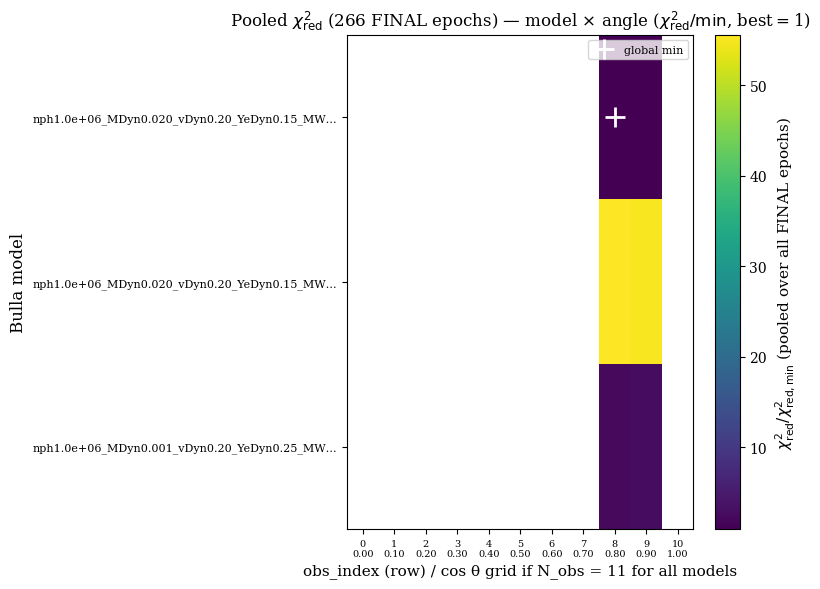

In [32]:
# --- Heatmap: pooled chi2_red for every (model file, observer index) ---
MAT_HM_BULLA_DIR = os.path.join(_REPO, "2023_bulla")
MAT_HM_MAX_MODELS = None
MAT_HM_UNCERTAINTY_SCALE = 1.0
MAT_HM_USE_LOG_NORM = False  # True if contrast is hard to see
MAT_HM_AUTO_SCALE_DISPLAY = True  # same as POOL_ALL: χ²_red / min(grid) so best cell = 1
MAT_HM_TOP_K = 15
# Restrict heatmap rows to θ band (skip χ² outside band; columns stay NaN)
MAT_HM_THETA_BAND_ONLY = True
MAT_HM_THETA_LO_DEG = 13.0
MAT_HM_THETA_HI_DEG = 45.0
FIG_SAVE_PATH_MAT_HM = None
FIG_SAVE_DPI_MAT_HM = FIG_SAVE_DPI

phase_rows_hm = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
if not phase_rows_hm:
    raise ValueError("No FINAL spectra for model×angle heatmap")
epochs_mat_hm = []
for row_hm in phase_rows_hm:
    path_hm = os.path.join(data_dir, row_hm["fname"])
    wl_hm, F_hm, fe_hm = read_final_spectrum_linear(
        path_hm, flux_on_disk=FINAL_FLUX_ON_DISK
    )
    mk = np.isfinite(wl_hm) & np.isfinite(F_hm) & np.isfinite(fe_hm)
    wl_hm, F_hm, fe_hm = wl_hm[mk], F_hm[mk], fe_hm[mk]
    ord_hm = np.argsort(wl_hm)
    wl_hm, F_hm, fe_hm = wl_hm[ord_hm], F_hm[ord_hm], fe_hm[ord_hm]
    wl_hm, F_hm, fe_hm = deduplicate_wavelength_flux(wl_hm, F_hm, fe_hm)
    epochs_mat_hm.append(
        {
            "wl_data": wl_hm,
            "F_data": F_hm,
            "fe_data": fe_hm,
            "phase_model_days": float(row_hm["phase_days"])
            + float(MODEL_PHASE_OFFSET_DAYS),
        }
    )

hm_paths = sorted(glob.glob(os.path.join(MAT_HM_BULLA_DIR, "*.hdf5")))
if MAT_HM_MAX_MODELS is not None:
    hm_paths = hm_paths[: int(MAT_HM_MAX_MODELS)]

if not hm_paths:
    print("No *.hdf5 in", MAT_HM_BULLA_DIR)
else:
    n_ang_max = 0
    for hp in hm_paths:
        bb = load_bulla_observables(hp)
        n_ang_max = max(n_ang_max, bb["I_stokes"].shape[0])

    Z_hm = np.full((len(hm_paths), n_ang_max), np.nan, dtype=float)
    y_labels = []
    flat_records = []

    for mi, hp in enumerate(hm_paths):
        stem_hm = os.path.splitext(os.path.basename(hp))[0]
        y_labels.append(stem_hm[:42] + ("…" if len(stem_hm) > 42 else ""))
        blob_hm = load_bulla_observables(hp)
        n_o = blob_hm["I_stokes"].shape[0]
        band_oi = None
        if MAT_HM_THETA_BAND_ONLY:
            band_oi = set(
                obs_indices_for_theta_deg_range(
                    n_o, MAT_HM_THETA_LO_DEG, MAT_HM_THETA_HI_DEG
                )
            )
        for oi in range(n_o):
            if band_oi is not None and oi not in band_oi:
                continue
            c2h, nh = pooled_chi2_all_epochs_angles(
                blob_hm,
                epochs_mat_hm,
                z=z,
                d_lum_mpc=d_lum_mpc,
                wave_is_rest=WAVE_IS_REST,
                time_interp=TIME_INTERP_MODEL,
                uncertainty_scale=MAT_HM_UNCERTAINTY_SCALE,
                obs_indices=[oi],
            )
            cr = float(c2h) / float(nh) if nh > 0 else float("nan")
            Z_hm[mi, oi] = cr
            flat_records.append(
                {
                    "model_stem": stem_hm,
                    "obs_index": oi,
                    "chi2_red": cr,
                }
            )

    tab_flat = pd.DataFrame(flat_records)
    tab_flat = tab_flat[np.isfinite(tab_flat["chi2_red"])].sort_values("chi2_red")
    chi2_hm_min = (
        float(tab_flat["chi2_red"].min()) if len(tab_flat) > 0 else float("nan")
    )
    if (
        MAT_HM_AUTO_SCALE_DISPLAY
        and np.isfinite(chi2_hm_min)
        and chi2_hm_min > 0
    ):
        Z_hm_plot = Z_hm / chi2_hm_min
        tab_flat["chi2_red_display"] = tab_flat["chi2_red"] / chi2_hm_min
        _hm_scaled = True
    else:
        Z_hm_plot = Z_hm
        tab_flat["chi2_red_display"] = tab_flat["chi2_red"]
        _hm_scaled = False

    print(
        "Top",
        MAT_HM_TOP_K,
        "(model, obs_index, chi2_red"
        + (", χ²_red/min" if _hm_scaled else "")
        + "):",
    )
    _cols = ["model_stem", "obs_index", "chi2_red"]
    if _hm_scaled:
        _cols.append("chi2_red_display")
    print(tab_flat.head(MAT_HM_TOP_K)[_cols].to_string(index=False))

    from matplotlib.colors import LogNorm

    fig_hm, ax_hm = plt.subplots(
        figsize=(max(8.0, 0.45 * n_ang_max), max(6.0, 0.35 * len(hm_paths))),
    )
    Zm = np.ma.masked_invalid(Z_hm_plot)
    if MAT_HM_USE_LOG_NORM:
        vmin = float(np.nanmin(Z_hm_plot))
        if vmin <= 0 or not np.isfinite(vmin):
            norm_hm = None
        else:
            norm_hm = LogNorm(vmin=vmin, vmax=float(np.nanmax(Z_hm_plot)))
    else:
        norm_hm = None

    im_hm = ax_hm.imshow(
        Zm,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        norm=norm_hm,
    )
    ax_hm.set_yticks(np.arange(len(hm_paths)))
    ax_hm.set_yticklabels(y_labels, fontsize=8)
    ax_hm.set_xticks(np.arange(n_ang_max))
    x_cos = np.linspace(0.0, 1.0, n_ang_max)
    ax_hm.set_xticklabels(
        ["%d\n%.2f" % (j, x_cos[j]) for j in range(n_ang_max)],
        fontsize=7,
    )
    ax_hm.set_xlabel("obs_index (row) / cos θ grid if N_obs = %d for all models" % n_ang_max, fontsize=11)
    ax_hm.set_ylabel("Bulla model", fontsize=12)
    ax_hm.set_title(
        (
            r"Pooled $\chi^2_{\rm red}$ (%d FINAL epochs) — model $\times$ angle ($\chi^2_{\rm red}/\min$, best$=$1)"
            if _hm_scaled
            else r"Pooled $\chi^2_{\rm red}$ (%d FINAL epochs) — model $\times$ angle"
        )
        % len(epochs_mat_hm)
    )
    cbar_hm = fig_hm.colorbar(im_hm, ax=ax_hm)
    cbar_hm.set_label(
        (
            r"$\chi^2_{\rm red} / \chi^2_{\rm red, min}$ (pooled over all FINAL epochs)"
            if _hm_scaled
            else r"$\chi^2_{\rm red}$ (pooled over all FINAL epochs)"
        ),
        fontsize=11,
    )

    # Mark global minimum on the grid (same cell for raw and scaled maps)
    if np.any(np.isfinite(Z_hm)):
        ij = np.unravel_index(int(np.nanargmin(Z_hm)), Z_hm.shape)
        ax_hm.plot(ij[1], ij[0], "w+", ms=14, mew=2, label="global min")
        ax_hm.legend(loc="upper right", fontsize=8)

    fig_hm.tight_layout()
    if FIG_SAVE_PATH_MAT_HM:
        fig_hm.savefig(
            FIG_SAVE_PATH_MAT_HM, dpi=FIG_SAVE_DPI_MAT_HM, bbox_inches="tight"
        )
    plt.show()

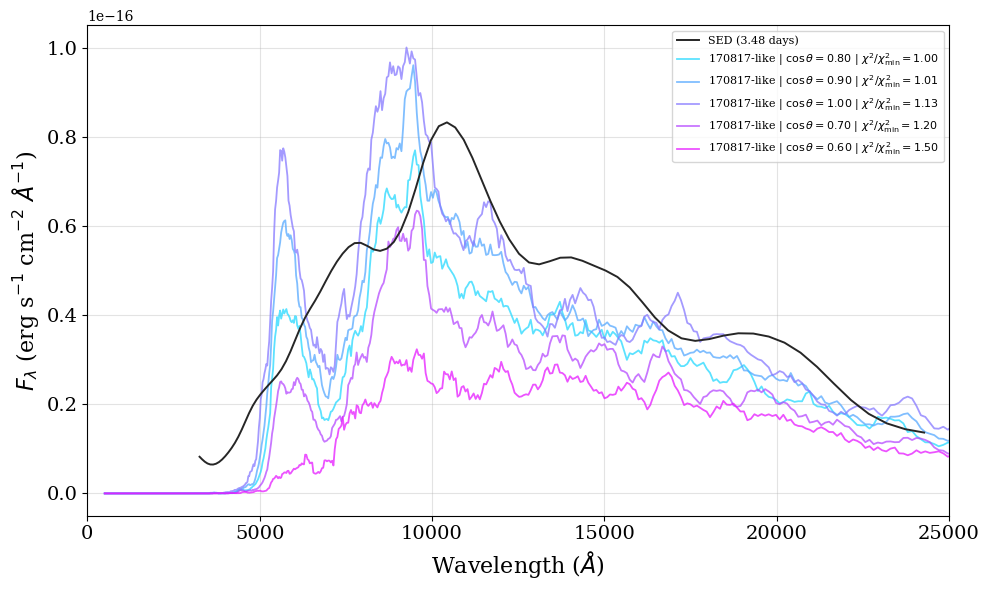

In [31]:
# --- Plot top-5 Bulla models (uses heatmap ranking only; run heatmap cell first) ---
# Does not recompute χ²: plots the first HM_TOP5_N_MODELS `(model_stem, obs_index)` rows of sorted `tab_flat` (same HDF5 may appear more than once at different angles).
# Legend entries: optional name (HM_TOP5_DISPLAY_NAMES), θ at obs_index, χ²_red and optional χ²/χ²_min.

HM_TOP5_PHASE_DAYS = 3.5  # days since t0 (nearest FINAL spectrum)
HM_TOP5_N_MODELS = 5
#FIGSAVE_HM_TOP5 = '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/plots-for-flash/model_comparison_7.5days.png'

# Moving-average half-width in native model spectral pixels (0 disables)
HM_TOP5_MODEL_SMOOTH_HALFWIN_PIX = 3
HM_TOP5_DISPLAY_NAMES = {}
FIGSAVE_HM_TOP5 = None

# Display names keyed by ``model_stem`` (HDF5 basename without extension). Empty/absent keys → shortened stem (32 chars).
# If one model is plotted at two angles, the same display name applies to both curves; θ / χ² in the legend differentiate them.
# HM_TOP5_DISPLAY_NAMES = {
#      "nph1.0e+07_dyn0.005-0.20-0.20_wind0.050_fiducial_dyncontr": "Fiducial DynContr",
#      "nph1.0e+07_dyn0.005-0.20-0.20_wind0.050_fiducial_dyncontr": "Fiducial DynContr",
#      "nph1.0e+07_dyn0.005-0.20-0.20_wind0.050_fiducial": "Fiducial",
#      "nph2.0e+06_dyn0.005-0.20-0.20_wind0.050_simpleall_run1": "Simple All",
#      "nph2.0e+06_dyn0.005-0.20-0.20_wind0.050_simpleall_run3": "Simple All",
# }
HM_TOP5_DISPLAY_NAMES = {
     "nph1.0e+06_MDyn0.001_vDyn0.20_YeDyn0.25_MWind0.130_vWind0.15_YeWind0.40": "high Ye",
     "nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.20": "low Ye",
     "nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.40": "170817-like",
}

# "red" = χ²_red only. "red_and_norm" = χ²_red plus χ²/χ²_min (same as chi2_red_display when present).
HM_TOP5_LABEL_CHI2_MODE = "red_and_norm"

# If True, append cos(theta) on the grid next to θ.
HM_TOP5_LABEL_SHOW_COS_THETA = True

HM_TOP5_LEGEND_FONTSIZE = 8

stem_to_path_hm = {
    os.path.splitext(os.path.basename(p))[0]: p for p in hm_paths
}
_chi_ref = float(tab_flat["chi2_red"].min()) if len(tab_flat) > 0 else float("nan")


def hm_top5_smooth_model_flux(flux, halfwin_pix):
    flux = np.asarray(flux, dtype=float)
    hw = int(halfwin_pix)
    if hw <= 0 or flux.size < 3:
        return flux
    w = 2 * hw + 1
    k = np.ones(w, dtype=float) / float(w)
    return np.convolve(flux, k, mode="same")


def hm_top5_normalized_chi2(row):
    if "chi2_red_display" in row.index and np.isfinite(
        row["chi2_red_display"]
    ):
        return float(row["chi2_red_display"])
    if np.isfinite(_chi_ref) and _chi_ref > 0:
        return float(row["chi2_red"]) / _chi_ref
    return float(row["chi2_red"])


def hm_top5_display_name_for_row(row):
    st = str(row["model_stem"])
    if st in HM_TOP5_DISPLAY_NAMES and str(HM_TOP5_DISPLAY_NAMES[st]).strip():
        return str(HM_TOP5_DISPLAY_NAMES[st])
    return st[:32] + ("…" if len(st) > 32 else "")


_rows_hm_top5 = []
_hm_top5_skipped_no_path = 0
for _, _rhm in tab_flat.iterrows():
    _sthm = _rhm["model_stem"]
    if _sthm not in stem_to_path_hm:
        _hm_top5_skipped_no_path += 1
        continue
    _rows_hm_top5.append(_rhm)
    if len(_rows_hm_top5) >= int(HM_TOP5_N_MODELS):
        break

if _hm_top5_skipped_no_path > 0:
    print(
        "HM top5: skipped %d tab_flat row(s): model_stem not in stem_to_path_hm (re-run heatmap cell or align hm_paths)."
        % _hm_top5_skipped_no_path,
    )

if len(_rows_hm_top5) == 0:
    raise ValueError(
        "No rows to plot — run the heatmap cell first or check tab_flat / hm_paths."
    )

_phrows_hmtp = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
_picked_hmtp = pick_final_by_nearest_phase(
    _phrows_hmtp, float(HM_TOP5_PHASE_DAYS)
)
_path_hmtp = os.path.join(data_dir, _picked_hmtp["fname"])
wl_htp, F_htp, fe_htp = read_final_spectrum_linear(
    _path_hmtp, flux_on_disk=FINAL_FLUX_ON_DISK
)
_mhtp = np.isfinite(wl_htp) & np.isfinite(F_htp) & np.isfinite(fe_htp)
wl_htp, F_htp, fe_htp = wl_htp[_mhtp], F_htp[_mhtp], fe_htp[_mhtp]
_ohtp = np.argsort(wl_htp)
wl_htp, F_htp, fe_htp = wl_htp[_ohtp], F_htp[_ohtp], fe_htp[_ohtp]
wl_htp, F_htp, fe_htp = deduplicate_wavelength_flux(wl_htp, F_htp, fe_htp)

phase_model_hmtp = float(_picked_hmtp["phase_days"]) + float(MODEL_PHASE_OFFSET_DAYS)

plt.rcParams["font.family"] = "serif"
fig_htp, ax_htp = plt.subplots(figsize=FIGSIZE)
ax_htp.plot(
    wl_htp,
    F_htp,
    color="0.15",
    lw=1.4,
    label="SED (%.2f days)" % float(_picked_hmtp["phase_days"]),
    zorder=1000,
)
# ax_htp.fill_between(
#     wl_htp,
#     F_htp - fe_htp,
#     F_htp + fe_htp,
#     color="0.15",
#     alpha=0.2,
# )

cmap_htp = plt.cm.cool
_nmtp = max(len(_rows_hm_top5), 1)
for _kmtp, _rmtp in enumerate(_rows_hm_top5):
    _blob_htp = load_bulla_observables(stem_to_path_hm[_rmtp["model_stem"]])
    _n_obs_htp = int(_blob_htp["I_stokes"].shape[0])
    _cos_grid_htp, _th_grid_htp = cos_theta_to_theta_deg(_n_obs_htp)
    _oi_htp = int(_rmtp["obs_index"])
    if not (0 <= _oi_htp < _n_obs_htp):
        raise IndexError(
            "obs_index %d out of range [0,%d) for model %r"
            % (_oi_htp, _n_obs_htp, _rmtp["model_stem"])
        )
    _theta_deg_plot = float(_th_grid_htp[_oi_htp])
    _cos_theta_plot = float(_cos_grid_htp[_oi_htp])
    wl_mm, F_mm, _ = model_flux_for_epoch_and_angle(
        _blob_htp,
        obs_index=_oi_htp,
        phase_days_target=phase_model_hmtp,
        z=z,
        d_lum_mpc=d_lum_mpc,
        wave_is_rest=WAVE_IS_REST,
        time_interp=TIME_INTERP_MODEL,
    )
    if int(HM_TOP5_MODEL_SMOOTH_HALFWIN_PIX) != 0:
        F_mm = hm_top5_smooth_model_flux(
            F_mm, HM_TOP5_MODEL_SMOOTH_HALFWIN_PIX
        )
    clr = cmap_htp(0.15 + 0.75 * _kmtp / max(_nmtp - 1, 1))
    _stem_label = hm_top5_display_name_for_row(_rmtp)
    _chi_red_lab = float(_rmtp["chi2_red"])
    _theta_cos_extra = ""
    if HM_TOP5_LABEL_SHOW_COS_THETA:
        _theta_cos_extra = r"$\cos\theta=%.2f$" % _cos_theta_plot
    _theta_latex = r"$\theta=%.1f^\circ%s$" % (_theta_deg_plot, _theta_cos_extra)
    if HM_TOP5_LABEL_CHI2_MODE == "red":
        _chi_latex = r"$\chi^2_{\mathrm{red}}=%.4g$" % _chi_red_lab
    elif HM_TOP5_LABEL_CHI2_MODE == "red_and_norm":
        _chi_latex = (
            r"$\chi^2/\chi^2_{\mathrm{min}}=%.2f$"
            % (hm_top5_normalized_chi2(_rmtp))
        )
    else:
        raise ValueError(
            "HM_TOP5_LABEL_CHI2_MODE must be 'red' or 'red_and_norm', got %r"
            % (HM_TOP5_LABEL_CHI2_MODE,)
        )
    _leg_lab = "%s | %s | %s" % (_stem_label, _theta_cos_extra, _chi_latex)
    ax_htp.plot(
        wl_mm,
        F_mm,
        lw=1.3,
        alpha=0.75,
        color=clr,
        label=_leg_lab,
    )



ax_htp.set_xlim(0, 25000)
ax_htp.set_xlabel(r"Wavelength ($\AA$)", fontsize=16)
ax_htp.set_ylabel(r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)", fontsize=16)
ax_htp.tick_params(axis='both', which='major', labelsize=14)
# ax_htp.set_title(
#     "%s | phase=%.2f d (target %.2f d) | top %d (model×θ) | z=%.5f $D_L$=%.1f Mpc"
#     % (
#         SNNAME,
#         float(_picked_hmtp["phase_days"]),
#         float(HM_TOP5_PHASE_DAYS),
#         len(_rows_hm_top5),
#         z,
#         d_lum_mpc,
#     )
# )
ax_htp.legend(loc="best", fontsize=HM_TOP5_LEGEND_FONTSIZE)
ax_htp.grid(True, alpha=0.35)
fig_htp.tight_layout()
if FIGSAVE_HM_TOP5:
    fig_htp.savefig(
        FIGSAVE_HM_TOP5,
        dpi=500,
        bbox_inches="tight",
    )
plt.show()

### 2019 Bulla ASCII models (`2019_bulla/*.txt`): pooled $\chi^2_{\rm red}$ with **overlap-only** pooling

Ranking uses ``pooled_chi2_all_epochs_angles(..., restrict_to_overlap=True)``: FINAL epochs whose phase lies **outside** the model ``time_days`` range are dropped entirely, and for each retained epoch wavelengths are trimmed to the **spectral intersection** (observer-frame model $\lambda$ extent vs finite data pixels). Optionally restrict angles with ``MAT_2019_THETA_BAND_ONLY`` (same helper as HDF5).

**Flux reference distance:** 2019 ``.txt`` natives are F$_\lambda$ at **10 pc** (``load_bulla2019_txt`` sets ``reference_distance_mpc = 1e-5``; Bulla ``make_lcs.py``); HDF5 models use natives at **implicit 1 Mpc** (``load_bulla_observables`` sets ``reference_distance_mpc = 1.0``; ``make_lcs_hdf5.py``). ``model_flux_for_epoch_and_angle`` applies ``(D_\mathrm{ref}/D_L)^2/(1+z)`` from the blob—no notebook switch needed between formats.

Reuse ``data_dir``, ``SNNAME``, ``z``, ``d_lum_mpc``, ``t0``, ``FINAL_SUFFIXES_TO_LOAD``, ``MODEL_PHASE_OFFSET_DAYS``, ``WAVE_IS_REST``, ``TIME_INTERP_MODEL`` from earlier cells.


2019 Bulla txt | Top 15 (model, obs_index, chi2_red, χ²_red/min) [overlap pooled]:
                       model_stem  obs_index   chi2_red  chi2_red_display
nph1.0e+06_mej0.04_phi75_T7.0e+03          1 311.017534          1.000000
nph1.0e+06_mej0.04_phi75_T7.0e+03          0 311.305152          1.000925
nph1.0e+06_mej0.04_phi75_T7.0e+03          2 311.325599          1.000991
nph1.0e+06_mej0.04_phi75_T7.0e+03          3 312.229698          1.003897
nph1.0e+06_mej0.04_phi75_T7.0e+03          4 313.510619          1.008016
nph1.0e+06_mej0.04_phi75_T7.0e+03          5 315.739735          1.015183
nph1.0e+06_mej0.04_phi75_T7.0e+03          6 318.877147          1.025271
nph1.0e+06_mej0.04_phi75_T7.0e+03          7 324.534052          1.043459
nph1.0e+06_mej0.04_phi75_T7.0e+03          8 335.525917          1.078801
nph1.0e+06_mej0.04_phi75_T7.0e+03          9 366.563031          1.178593
nph1.0e+06_mej0.04_phi75_T7.0e+03         10 525.545111          1.689760
nph1.0e+06_mej0.04_phi30_T7.0

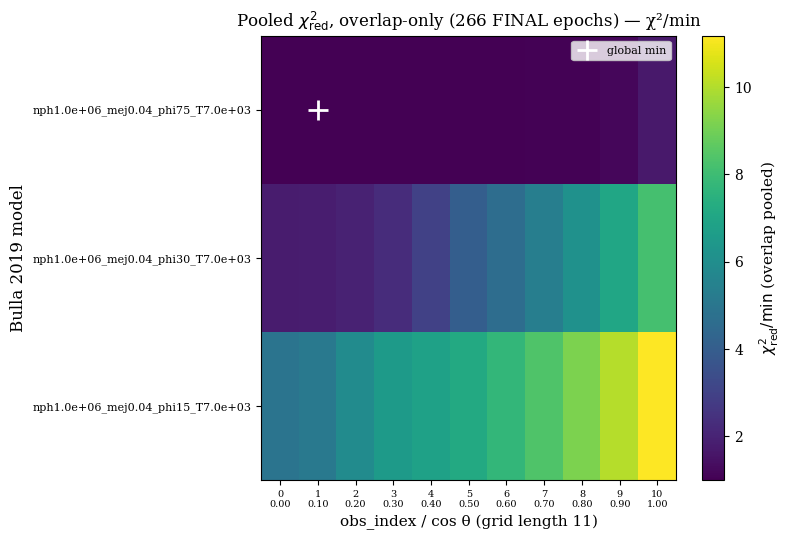

In [18]:
# --- 2019 txt: pooled chi2_red (overlap-only) vs every (model × obs_index) ---
MAT_2019_DIR = os.path.join(_REPO, "2019_bulla")
MAT_2019_MAX_MODELS = None
MAT_2019_UNCERTAINTY_SCALE = 1.0
MAT_2019_USE_LOG_NORM = False
MAT_2019_AUTO_SCALE_DISPLAY = True  # χ²_red / min(grid): best row = 1
MAT_2019_TOP_K = 15
MAT_2019_THETA_BAND_ONLY = False
MAT_2019_THETA_LO_DEG = 13.0
MAT_2019_THETA_HI_DEG = 45.0
MAT_2019_MIN_PIX_PER_EPOCH = 1
FIG_SAVE_PATH_MAT_2019 = None
FIG_SAVE_DPI_MAT_2019 = FIG_SAVE_DPI

phase_rows_2019 = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
if not phase_rows_2019:
    raise ValueError("No FINAL spectra for 2019 Bulla txt heatmap")
epochs_mat_2019 = []
for row_19 in phase_rows_2019:
    path_19 = os.path.join(data_dir, row_19["fname"])
    wl_19, F_19, fe_19 = read_final_spectrum_linear(
        path_19, flux_on_disk=FINAL_FLUX_ON_DISK
    )
    mk19 = np.isfinite(wl_19) & np.isfinite(F_19) & np.isfinite(fe_19)
    wl_19, F_19, fe_19 = wl_19[mk19], F_19[mk19], fe_19[mk19]
    ord19 = np.argsort(wl_19)
    wl_19, F_19, fe_19 = wl_19[ord19], F_19[ord19], fe_19[ord19]
    wl_19, F_19, fe_19 = deduplicate_wavelength_flux(wl_19, F_19, fe_19)
    epochs_mat_2019.append(
        {
            "wl_data": wl_19,
            "F_data": F_19,
            "fe_data": fe_19,
            "phase_model_days": float(row_19["phase_days"])
            + float(MODEL_PHASE_OFFSET_DAYS),
        }
    )

txt_paths = sorted(glob.glob(os.path.join(MAT_2019_DIR, "*.txt")))
if MAT_2019_MAX_MODELS is not None:
    txt_paths = txt_paths[: int(MAT_2019_MAX_MODELS)]

if not txt_paths:
    print("No *.txt in", MAT_2019_DIR)
else:
    n_ang_max19 = 0
    for tp in txt_paths:
        bb19 = load_bulla2019_txt(tp)
        n_ang_max19 = max(n_ang_max19, bb19["I_stokes"].shape[0])

    Z_19 = np.full((len(txt_paths), n_ang_max19), np.nan, dtype=float)
    y_labels_19 = []
    flat_records_19 = []

    for mi19, tp in enumerate(txt_paths):
        stem_19 = os.path.splitext(os.path.basename(tp))[0]
        y_labels_19.append(stem_19[:42] + ("…" if len(stem_19) > 42 else ""))
        blob19 = load_bulla2019_txt(tp)
        n_o19 = blob19["I_stokes"].shape[0]
        band_oi19 = None
        if MAT_2019_THETA_BAND_ONLY:
            band_oi19 = set(
                obs_indices_for_theta_deg_range(
                    n_o19, MAT_2019_THETA_LO_DEG, MAT_2019_THETA_HI_DEG
                )
            )
        for oi19 in range(n_o19):
            if band_oi19 is not None and oi19 not in band_oi19:
                continue
            c2_19, n_19_pix = pooled_chi2_all_epochs_angles(
                blob19,
                epochs_mat_2019,
                z=z,
                d_lum_mpc=d_lum_mpc,
                wave_is_rest=WAVE_IS_REST,
                time_interp=TIME_INTERP_MODEL,
                uncertainty_scale=MAT_2019_UNCERTAINTY_SCALE,
                obs_indices=[oi19],
                restrict_to_overlap=True,
                min_pix_per_epoch=int(MAT_2019_MIN_PIX_PER_EPOCH),
            )
            cr19 = float(c2_19) / float(n_19_pix) if n_19_pix > 0 else float("nan")
            Z_19[mi19, oi19] = cr19
            flat_records_19.append(
                {
                    "model_stem": stem_19,
                    "obs_index": oi19,
                    "chi2_red": cr19,
                }
            )

    tab_flat_2019 = pd.DataFrame(flat_records_19)
    tab_flat_2019 = tab_flat_2019[np.isfinite(tab_flat_2019["chi2_red"])].sort_values(
        "chi2_red"
    )
    chi2_19_min = (
        float(tab_flat_2019["chi2_red"].min())
        if len(tab_flat_2019) > 0
        else float("nan")
    )
    if MAT_2019_AUTO_SCALE_DISPLAY and np.isfinite(chi2_19_min) and chi2_19_min > 0:
        Z_19_plot = Z_19 / chi2_19_min
        tab_flat_2019["chi2_red_display"] = tab_flat_2019["chi2_red"] / chi2_19_min
        _19_scaled = True
    else:
        Z_19_plot = Z_19
        tab_flat_2019["chi2_red_display"] = tab_flat_2019["chi2_red"]
        _19_scaled = False

    print(
        "2019 Bulla txt | Top",
        MAT_2019_TOP_K,
        "(model, obs_index, chi2_red"
        + (", χ²_red/min" if _19_scaled else "")
        + ") [overlap pooled]:",
    )
    cols19 = ["model_stem", "obs_index", "chi2_red"]
    if _19_scaled:
        cols19.append("chi2_red_display")
    print(tab_flat_2019.head(MAT_2019_TOP_K)[cols19].to_string(index=False))

    from matplotlib.colors import LogNorm

    fig19, ax19 = plt.subplots(
        figsize=(max(8.0, 0.45 * n_ang_max19), max(5.5, 0.35 * len(txt_paths))),
    )
    Zm19 = np.ma.masked_invalid(Z_19_plot)
    if MAT_2019_USE_LOG_NORM:
        vmin19 = float(np.nanmin(Z_19_plot))
        norm19 = (
            LogNorm(vmin=vmin19, vmax=float(np.nanmax(Z_19_plot)))
            if vmin19 > 0 and np.isfinite(vmin19)
            else None
        )
    else:
        norm19 = None

    im19 = ax19.imshow(
        Zm19,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        norm=norm19,
    )
    ax19.set_yticks(np.arange(len(txt_paths)))
    ax19.set_yticklabels(y_labels_19, fontsize=8)
    ax19.set_xticks(np.arange(n_ang_max19))
    x_cos19 = np.linspace(0.0, 1.0, n_ang_max19)
    ax19.set_xticklabels(
        ["%d\n%.2f" % (j, x_cos19[j]) for j in range(n_ang_max19)],
        fontsize=7,
    )
    ax19.set_xlabel(
        "obs_index / cos θ (grid length %d)" % n_ang_max19, fontsize=11
    )
    ax19.set_ylabel("Bulla 2019 model", fontsize=12)
    ax19.set_title(
        (
            r"Pooled $\chi^2_{\rm red}$, overlap-only (%d FINAL epochs) — χ²/min"
            % len(epochs_mat_2019)
            if _19_scaled
            else r"Pooled $\chi^2_{\rm red}$, overlap-only (%d FINAL epochs)"
            % len(epochs_mat_2019)
        )
    )
    cbar19 = fig19.colorbar(im19, ax=ax19)
    cbar19.set_label(
        (
            r"$\chi^2_{\rm red} / \min$ (overlap pooled)"
            if _19_scaled
            else r"$\chi^2_{\rm red}$ (overlap pooled)"
        ),
        fontsize=11,
    )
    if np.any(np.isfinite(Z_19)):
        ij19 = np.unravel_index(int(np.nanargmin(Z_19)), Z_19.shape)
        ax19.plot(ij19[1], ij19[0], "w+", ms=14, mew=2, label="global min")
        ax19.legend(loc="upper right", fontsize=8)
    fig19.tight_layout()
    if FIG_SAVE_PATH_MAT_2019:
        fig19.savefig(
            FIG_SAVE_PATH_MAT_2019, dpi=FIG_SAVE_DPI_MAT_2019, bbox_inches="tight"
        )
    plt.show()

    stem_to_path_2019 = {os.path.splitext(os.path.basename(p))[0]: p for p in txt_paths}


### 2019(txt) overlay — best/worst $(\mathrm{model}, \theta)$ from ``tab_flat_2019``

Run the **overlap-pooled heatmap cell** above first so ``tab_flat_2019`` and ``stem_to_path_2019`` exist.


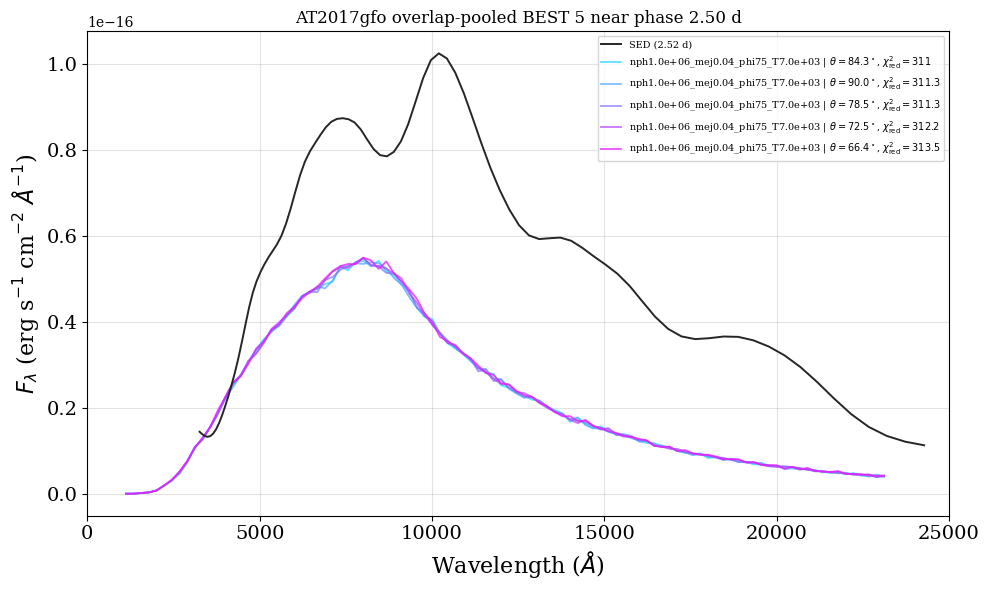

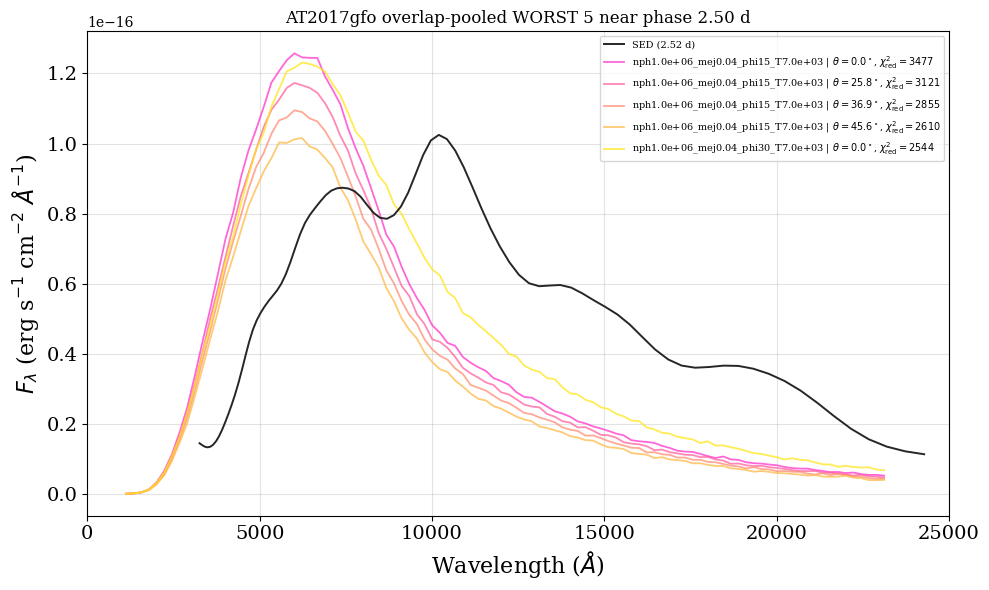

In [19]:
# --- Overlay best/worst 2019 models at one FINAL spectrum (nearest phase) ---
MAT_2019_OVERLAY_K = 5
MAT_2019_OVERLAY_SELECTION = "both"  # "best" | "worst" | "both"
MAT_2019_PHASE_DAYS = 2.5
FIGSAVE_MAT_2019_OVERLAY = None

_selection = str(MAT_2019_OVERLAY_SELECTION).strip().lower()
if _selection not in ("best", "worst", "both"):
    raise ValueError(
        "MAT_2019_OVERLAY_SELECTION must be 'best', 'worst', or 'both', got %r"
        % (MAT_2019_OVERLAY_SELECTION,)
    )

_tab19 = tab_flat_2019 if "tab_flat_2019" in globals() else None
_stems19 = stem_to_path_2019 if "stem_to_path_2019" in globals() else None
if _tab19 is None or _stems19 is None:
    raise RuntimeError(
        "Run the 2019 overlap heatmap cell first (defines tab_flat_2019 / stem_to_path_2019)."
    )

_pick19 = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
_near19 = pick_final_by_nearest_phase(_pick19, float(MAT_2019_PHASE_DAYS))
_path19 = os.path.join(data_dir, _near19["fname"])
wl_o19, F_o19, fe_o19 = read_final_spectrum_linear(
    _path19, flux_on_disk=FINAL_FLUX_ON_DISK
)
_m19 = np.isfinite(wl_o19) & np.isfinite(F_o19) & np.isfinite(fe_o19)
wl_o19, F_o19, fe_o19 = wl_o19[_m19], F_o19[_m19], fe_o19[_m19]
_ord19 = np.argsort(wl_o19)
wl_o19, F_o19, fe_o19 = wl_o19[_ord19], F_o19[_ord19], fe_o19[_ord19]
wl_o19, F_o19, fe_o19 = deduplicate_wavelength_flux(wl_o19, F_o19, fe_o19)
phase_model_ov19 = float(_near19["phase_days"]) + float(MODEL_PHASE_OFFSET_DAYS)

plt.rcParams["font.family"] = "serif"

if _selection in ("best", "both"):
    ordered19 = (
        _tab19[np.isfinite(_tab19["chi2_red"])]
        .sort_values("chi2_red")
        .reset_index(drop=True)
    )
    rows_ov19 = []
    for _, rrr in ordered19.iterrows():
        stem = str(rrr["model_stem"])
        if stem not in _stems19:
            continue
        rows_ov19.append(rrr)
        if len(rows_ov19) >= int(MAT_2019_OVERLAY_K):
            break

    figb, axb = plt.subplots(figsize=FIGSIZE)
    axb.plot(
        wl_o19,
        F_o19,
        color="0.15",
        lw=1.4,
        label="SED (%.2f d)" % float(_near19["phase_days"]),
        zorder=1000,
    )
    cmapb = plt.cm.cool
    nb = max(len(rows_ov19), 1)
    for kk, rr in enumerate(rows_ov19):
        stem = str(rr["model_stem"])
        blob_ov = load_bulla2019_txt(_stems19[stem])
        n_ov = int(blob_ov["I_stokes"].shape[0])
        oidx = int(rr["obs_index"])
        _cos_g19, th_g = cos_theta_to_theta_deg(n_ov)
        if not (0 <= oidx < n_ov):
            raise IndexError("obs_index %d out of [0,%d)" % (oidx, n_ov))
        wl_mm, F_mm, _ = model_flux_for_epoch_and_angle(
            blob_ov,
            obs_index=oidx,
            phase_days_target=phase_model_ov19,
            z=z,
            d_lum_mpc=d_lum_mpc,
            wave_is_rest=WAVE_IS_REST,
            time_interp=TIME_INTERP_MODEL,
        )
        clr = cmapb(0.15 + 0.75 * kk / max(nb - 1, 1))
        lab = r"%s | $\theta=%.1f^\circ$, $\chi^2_{\mathrm{red}}=%.4g$" % (
            stem[:35] + ("…" if len(stem) > 35 else ""),
            float(th_g[oidx]),
            float(rr["chi2_red"]),
        )
        axb.plot(wl_mm, F_mm, lw=1.3, alpha=0.75, color=clr, label=lab)

    axb.set_xlim(0, 25000)
    axb.set_xlabel(r"Wavelength ($\AA$)", fontsize=16)
    axb.set_ylabel(r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)", fontsize=16)
    axb.tick_params(axis="both", which="major", labelsize=14)
    tit = "%s overlap-pooled BEST %d near phase %.2f d" % (
        SNNAME,
        len(rows_ov19),
        float(MAT_2019_PHASE_DAYS),
    )
    axb.set_title(tit, fontsize=12)
    axb.legend(loc="best", fontsize=7)
    axb.grid(True, alpha=0.35)
    figb.tight_layout()
    if FIGSAVE_MAT_2019_OVERLAY:
        bs, bx = os.path.splitext(str(FIGSAVE_MAT_2019_OVERLAY))
        outp_b = bs + "_best" + bx if _selection == "both" else str(FIGSAVE_MAT_2019_OVERLAY)
        figb.savefig(outp_b, dpi=500, bbox_inches="tight")
    plt.show()

if _selection in ("worst", "both"):
    worst19 = (
        _tab19[np.isfinite(_tab19["chi2_red"])]
        .sort_values("chi2_red", ascending=False)
        .reset_index(drop=True)
    )
    rows_w19 = []
    for _, rrr in worst19.iterrows():
        stem = str(rrr["model_stem"])
        if stem not in _stems19:
            continue
        rows_w19.append(rrr)
        if len(rows_w19) >= int(MAT_2019_OVERLAY_K):
            break

    figw, axw = plt.subplots(figsize=FIGSIZE)
    axw.plot(
        wl_o19,
        F_o19,
        color="0.15",
        lw=1.4,
        label="SED (%.2f d)" % float(_near19["phase_days"]),
        zorder=1000,
    )
    cmapw = plt.cm.spring
    nw = max(len(rows_w19), 1)
    for kk, rr in enumerate(rows_w19):
        stem = str(rr["model_stem"])
        blob_w = load_bulla2019_txt(_stems19[stem])
        n_wv = int(blob_w["I_stokes"].shape[0])
        oidx = int(rr["obs_index"])
        _cw19, th_g = cos_theta_to_theta_deg(n_wv)
        if not (0 <= oidx < n_wv):
            raise IndexError("obs_index %d out of [0,%d)" % (oidx, n_wv))
        wl_mm, F_mm, _ = model_flux_for_epoch_and_angle(
            blob_w,
            obs_index=oidx,
            phase_days_target=phase_model_ov19,
            z=z,
            d_lum_mpc=d_lum_mpc,
            wave_is_rest=WAVE_IS_REST,
            time_interp=TIME_INTERP_MODEL,
        )
        clr = cmapw(0.2 + 0.7 * kk / max(nw - 1, 1))
        lab = r"%s | $\theta=%.1f^\circ$, $\chi^2_{\mathrm{red}}=%.4g$" % (
            stem[:35] + ("…" if len(stem) > 35 else ""),
            float(th_g[oidx]),
            float(rr["chi2_red"]),
        )
        axw.plot(wl_mm, F_mm, lw=1.3, alpha=0.75, color=clr, label=lab)

    axw.set_xlim(0, 25000)
    axw.set_xlabel(r"Wavelength ($\AA$)", fontsize=16)
    axw.set_ylabel(r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)", fontsize=16)
    axw.tick_params(axis="both", which="major", labelsize=14)
    axw.set_title(
        "%s overlap-pooled WORST %d near phase %.2f d"
        % (SNNAME, len(rows_w19), float(MAT_2019_PHASE_DAYS)),
        fontsize=12,
    )
    axw.legend(loc="best", fontsize=7)
    axw.grid(True, alpha=0.35)
    figw.tight_layout()
    if FIGSAVE_MAT_2019_OVERLAY:
        bs, bx = os.path.splitext(str(FIGSAVE_MAT_2019_OVERLAY))
        outp_w = bs + "_worst" + bx if _selection == "both" else str(FIGSAVE_MAT_2019_OVERLAY)
        figw.savefig(outp_w, dpi=500, bbox_inches="tight")
    plt.show()


### Custom Bulla model vs SED (dict-driven)

**Dependencies:** run upstream cells so `data_dir`, `COCO_PATH`, `SNNAME`, `DATALC_PATH`, `t0`, `FINAL_SUFFIXES_TO_LOAD`, `FINAL_FLUX_ON_DISK`, `z`, `d_lum_mpc`, `MODEL_PHASE_OFFSET_DAYS`, `WAVE_IS_REST`, `TIME_INTERP_MODEL`, and `_REPO` exist.

**Smoothing recap:** In this notebook, **only** the HDF5 “Plot top‑5 Bulla models” cell applies optional boxcar smoothing along the model λ grid (`HM_TOP5_MODEL_SMOOTH_HALFWIN_PIX`). All other model spectrum plots, 2019 overlays, and **χ²** use **unsmoothed** `model_flux_for_epoch_and_angle` output. This block defaults to **no** model smoothing (`smooth_halfwin_pix_default = 0`) so curves match χ²; set a positive half-width to mimic the HM top‑5 plot.

**Config:** Edit `CUSTOM_BULLA_VS_SED` below: `sed_phase_days` picks the **nearest** FINAL spectrum; each `runs` entry can set `phase_days` explicitly (model time in days, **same convention as elsewhere**: usually `observed_phase + MODEL_PHASE_OFFSET_DAYS` if you match that spectrum’s epoch), or omit it to use the picked SED’s phase plus `MODEL_PHASE_OFFSET_DAYS`. Use `path` or `dir`+`filename`. Angle: `obs_index` **or** `cos_theta` **or** `theta_deg` (nearest grid point).


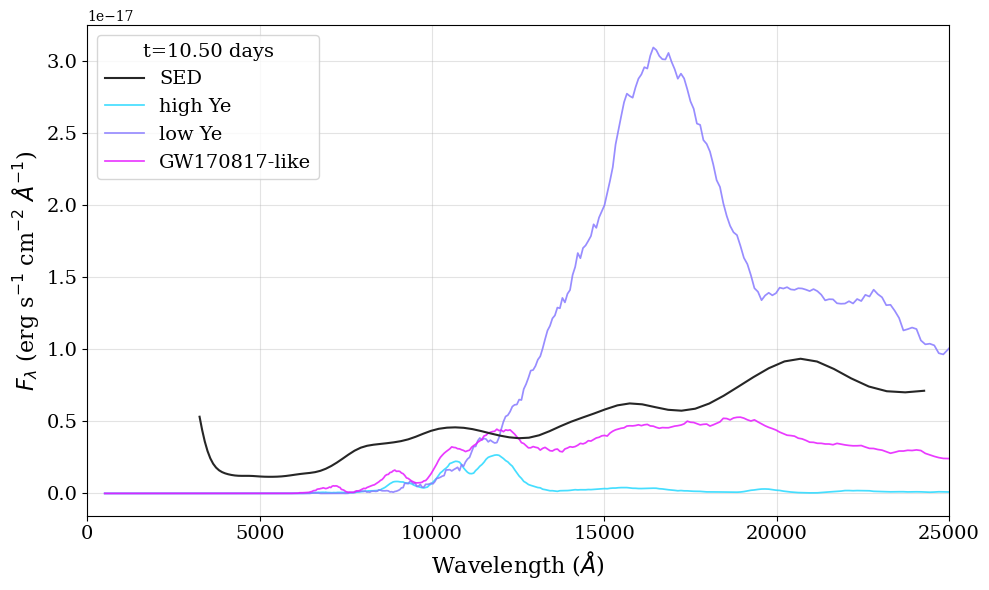

In [55]:
# --- Custom: one SED vs one or many Bulla models (HDF5 or 2019 .txt), dict config ---
#
# Examples (uncomment/adapt paths):
#
CUSTOM_BULLA_VS_SED = {
    "sed_phase_days": 10.5,
    "smooth_halfwin_pix_default": 3,
    "runs": [
        # {
        #     # Full path HDF5:
        #     "path": os.path.join(
        #         _REPO, "2019_bulla",
        #         "nph1.0e+06_mej0.04_phi15_T7.0e+03.txt",
        #     ),
        #     #"obs_index": 5,
        #     # Omit phase_days → use nearest SED epoch + MODEL_PHASE_OFFSET_DAYS
        #     # "phase_days": 7.518 + MODEL_PHASE_OFFSET_DAYS,
        #     "label": "HDF5 fiducial",
        #     # Optional per-run smoothing (boxcar half-width on native model λ bins)
        #     # "smooth_halfwin_pix": 3,
        # },
        {
            "dir": os.path.join(_REPO, "2023_bulla"),
            "filename": "nph1.0e+06_MDyn0.001_vDyn0.20_YeDyn0.25_MWind0.130_vWind0.15_YeWind0.40.hdf5",
            "theta_deg": 35.0,
            "label": "high Ye",
        },
        {
            "dir": os.path.join(_REPO, "2023_bulla"),
            "filename": "nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.20.hdf5",
            "theta_deg": 35.0,
            "label": "low Ye",
        },
        {
            "dir": os.path.join(_REPO, "2023_bulla"),
            "filename": "nph1.0e+06_MDyn0.020_vDyn0.20_YeDyn0.15_MWind0.130_vWind0.15_YeWind0.40.hdf5",
            "theta_deg": 35.0,
            "label": "GW170817-like",
        }
        ]
    }

def custom_overlay_smooth_model_flux(flux, halfwin_pix):
    """Same kernel as HM top-5 overlay: uniform boxcar on native model spectral axis."""
    flux = np.asarray(flux, dtype=float)
    hw = int(halfwin_pix)
    if hw <= 0 or flux.size < 3:
        return flux
    w = 2 * hw + 1
    k = np.ones(w, dtype=float) / float(w)
    return np.convolve(flux, k, mode="same")


def _custom_resolve_model_path(run):
    if run.get("path"):
        return os.path.abspath(str(run["path"]))
    dn = run.get("dir")
    fn = run.get("filename")
    if dn and fn:
        return os.path.abspath(os.path.join(str(dn), str(fn)))
    raise ValueError("Each run needs 'path' or ('dir' and 'filename')")


def _custom_load_bulla_blob(ppath):
    ext = os.path.splitext(ppath)[1].lower()
    if ext == ".hdf5":
        return load_bulla_observables(ppath), "hdf5"
    if ext == ".txt":
        return load_bulla2019_txt(ppath), "txt"
    raise ValueError("Expected .hdf5 or .txt model file, got %r" % ext)


def _custom_resolve_obs_index(blob, run):
    if run.get("obs_index") is not None:
        oi = int(run["obs_index"])
        return oi
    n_obs = blob["I_stokes"].shape[0]
    cos_grid, th_grid = cos_theta_to_theta_deg(n_obs)
    if run.get("cos_theta") is not None:
        return nearest_obs_index_for_cos_theta(cos_grid, float(run["cos_theta"]))
    if run.get("theta_deg") is not None:
        td = float(run["theta_deg"])
        return int(np.nanargmin(np.abs(th_grid - td)))
    raise ValueError("Run needs obs_index or cos_theta or theta_deg")


# CUSTOM_BULLA_VS_SED = {
#     "sed_phase_days": 7.5,
#     "smooth_halfwin_pix_default": 0,
#     "runs": [],  # add dicts OR paste examples above
# }


_cfg = CUSTOM_BULLA_VS_SED
_runs_cfg = list(_cfg.get("runs") or [])
if isinstance(_runs_cfg, dict):
    raise TypeError("'runs' must be a list of dicts")

_sed_ph = float(_cfg["sed_phase_days"])
_smooth_def = int(_cfg.get("smooth_halfwin_pix_default", 0))

_phase_rows_cu = enumerate_final_spectrum_phases(
    data_dir,
    COCO_PATH,
    SNNAME,
    DATALC_PATH,
    t0_mjd=float(t0),
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
)
_picked_cu = pick_final_by_nearest_phase(_phase_rows_cu, _sed_ph)
_path_cu = os.path.join(data_dir, _picked_cu["fname"])
wl_cu, F_cu, fe_cu = read_final_spectrum_linear(
    _path_cu, flux_on_disk=FINAL_FLUX_ON_DISK
)
_mcu = np.isfinite(wl_cu) & np.isfinite(F_cu) & np.isfinite(fe_cu)
wl_cu, F_cu, fe_cu = wl_cu[_mcu], F_cu[_mcu], fe_cu[_mcu]
_ocu = np.argsort(wl_cu)
wl_cu, F_cu, fe_cu = wl_cu[_ocu], F_cu[_ocu], fe_cu[_ocu]
wl_cu, F_cu, fe_cu = deduplicate_wavelength_flux(wl_cu, F_cu, fe_cu)

_default_phase_model = float(_picked_cu["phase_days"]) + float(MODEL_PHASE_OFFSET_DAYS)

if not _runs_cfg:
    print(
        "CUSTOM_BULLA_VS_SED['runs'] is empty — paste one or more overlay dicts and re-run."
    )
else:
    plt.rcParams["font.family"] = "serif"
    fig_cu, ax_cu = plt.subplots(figsize=FIGSIZE)
    ax_cu.plot(
        wl_cu,
        F_cu,
        color="0.15",
        lw=1.5,
        label="SED",
        zorder=100,
    )

    cmap_cu = plt.cm.cool
    n_cu = len(_runs_cfg)

    for j, rw in enumerate(_runs_cfg):
        pth = _custom_resolve_model_path(rw)
        blob_cu, fmt = _custom_load_bulla_blob(pth)
        zi = float(rw["z"]) if rw.get("z") is not None else float(z)
        dl = (
            float(rw["d_lum_mpc"])
            if rw.get("d_lum_mpc") is not None
            else float(d_lum_mpc)
        )
        oidx = _custom_resolve_obs_index(blob_cu, rw)
        n_bo = blob_cu["I_stokes"].shape[0]
        if not (0 <= oidx < n_bo):
            raise IndexError(
                "obs_index=%d invalid for blob with N_obs=%d (%s)"
                % (oidx, n_bo, pth)
            )
        phase_m = (
            float(rw["phase_days"])
            if rw.get("phase_days") is not None
            else _default_phase_model
        )
        shw = int(rw.get("smooth_halfwin_pix", _smooth_def))

        wl_mm, F_mm, _ = model_flux_for_epoch_and_angle(
            blob_cu,
            obs_index=oidx,
            phase_days_target=phase_m,
            z=zi,
            d_lum_mpc=dl,
            wave_is_rest=WAVE_IS_REST,
            time_interp=TIME_INTERP_MODEL,
        )
        if shw != 0:
            F_mm = custom_overlay_smooth_model_flux(F_mm, shw)

        stem = os.path.splitext(os.path.basename(pth))[0]
        _cos_g_cu, _th_cu = cos_theta_to_theta_deg(n_bo)
        th_plot = float(_th_cu[oidx])
        if rw.get("label"):
            legend_lbl = str(rw["label"])
        else:
            legend_lbl = "%s[%s] θ=%.1f° #%d%s" % (
                stem[:32] + ("…" if len(stem) > 32 else ""),
                fmt,
                th_plot,
                oidx,
                " sm%d" % shw if shw else "",
            )
        clr = cmap_cu(0.15 + 0.75 * j / max(n_cu - 1, 1))
        ax_cu.plot(wl_mm, F_mm, lw=1.25, alpha=0.85, color=clr, label=legend_lbl)

    ax_cu.set_xlim(0, 25000)
    ax_cu.set_xlabel(r"Wavelength ($\AA$)", fontsize=16)
    ax_cu.set_ylabel(
        r"$F_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)", fontsize=16
    )
    ax_cu.tick_params(axis="both", which="major", labelsize=14)
    # ax_cu.set_title(
    #     "%s | custom overlays | SED target phase %.2f d (Δ=%.3f d)"
    #     % (
    #         SNNAME,
    #         _sed_ph,
    #         float(_picked_cu["delta_phase_days"]),
    #     ),
    #     fontsize=12,
    # )
    #ax_cu.legend(loc="best", fontsize=14, title='t=%.2f days, $\\theta$=%.1f°' % (float(_picked_cu["phase_days"]), float(_th_cu[oidx])))
    ax_cu.legend(loc="upper left", fontsize=14, title_fontsize=14, title='t=%.2f days' % (float(_picked_cu["phase_days"])))

    ax_cu.grid(True, alpha=0.35)
    fig_cu.tight_layout()
    plt.savefig('/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/plots-for-flash/final_model_comparison_10.5days.png', dpi=500, bbox_inches='tight')
    plt.show()
